In [1]:
import sys
#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

#import cartopy
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
'''
sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")
#sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")
sys.path.insert(0,"/user/work/yl18410/.conda/envs/new_graphnet/lib/python3.12/site-packages")
'''
print(sys.path)


import torch
import os
import pickle
import einops

#import plenoptic as po
#sys.path.insert(0, "/user/work/yl18410/GCN/graphnet/")
#sys.path.insert(0, "/user/work/yl18410/graphnet_LPDM_emulator")
sys.path.insert(0, "/user/work/yl18410/new_graphnet")
sys.path.insert(0, "/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.loss_functions import *
#from graphnet_LPDM_emulator.model.evaluation import *

from sklearn.neural_network import MLPRegressor
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



['/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator', '/user/work/yl18410/graphnet_bp_220324_backup/lib/python39.zip', '/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9', '/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/lib-dynload', '', '/user/home/yl18410/.local/lib/python3.9/site-packages', '/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages']


/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def getint_updated(filename):
    basename = os.path.basename(filename)
    num_part = basename.split('_')[-1].split('.')[0]
    return int(num_part) if num_part.isdigit() else -1  # give non-numeric ones a low sort order

def get_checkpoint_to_load_updated(model_name, directory, prefer_best=True):
    print(f"loading checkpoint for {model_name}")
    
    model_dir = os.path.join(directory, model_name)
    best_path = os.path.join(model_dir, f"{model_name}_best.pt")
    
    if prefer_best and os.path.exists(best_path):
        print(f"Found best checkpoint: {best_path}")
        return best_path

    # Fallback: load the latest numbered checkpoint
    pattern = os.path.join(model_dir, f"{model_name}_*.pt")
    files = sorted(
        [f for f in glob.glob(pattern) if getint(f) != -1],
        key=getint
    )
    
    assert len(files) > 0, f"No numeric checkpoint files found for model name {model_name}"
    checkpoint_to_load = files[-1]
    print(f"Loading latest checkpoint: {checkpoint_to_load}")
    
    return checkpoint_to_load

def get_checkpoint_to_load(model_name,directory):
    print(f"loading last checkpoint for {model_name}")
    #directory="/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/"
    files = sorted(glob.glob(glob.escape(f"{directory}{model_name}/{model_name}_")+"*.pt"), key=getint)
    assert len(files)>0, f"no files found for model name {model_name}"
    checkpoint_to_load = files[-1] 
        
    return checkpoint_to_load 

def get_loss(model_name,directory):
    print(f"loading last checkpoint for {model_name}")
    #directory="/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/"
    print(f"{directory}{model_name}/{model_name}")
    files = sorted(glob.glob(glob.escape(f"{directory}{model_name}/{model_name}_")+"*.pt"), key=getint_updated)
    assert len(files)>0, f"no files found for model name {model_name}"
    checkpoint_to_load = files[-1] 
        
    checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))
    loss = checkpoint["loss"]
    return loss

def getint(name):
    num = name.split('_')[-1]
    num = num.split('.')[0]
    return int(num)


# Predicting a single value

loading checkpoint for num_classes-1_baselines-True_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-05_seed-42_date-Oct-11-2025
Found best checkpoint: /user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/boundary_condition/num_classes-1_baselines-True_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-05_seed-42_date-Oct-11-2025/num_classes-1_baselines-True_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-05_seed-42_date-Oct-11-2025_best.pt


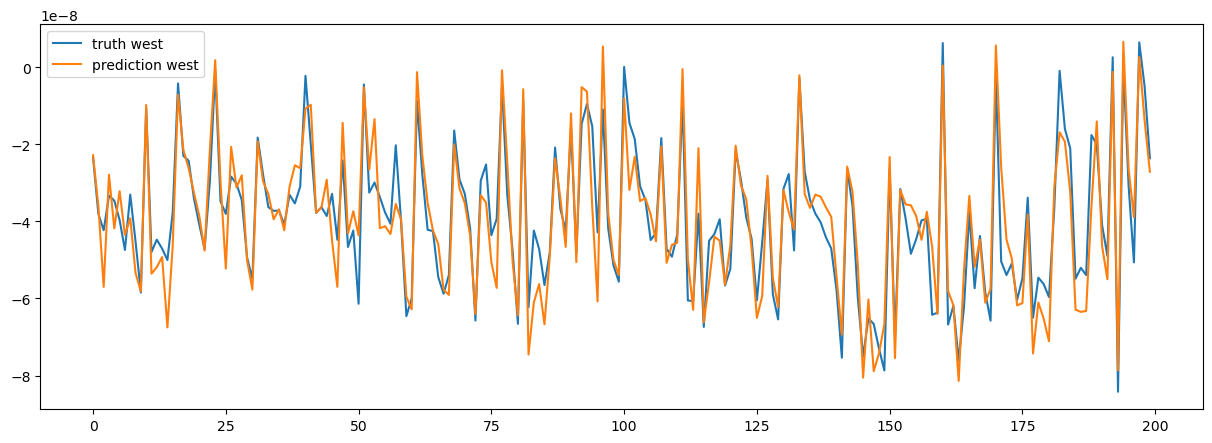

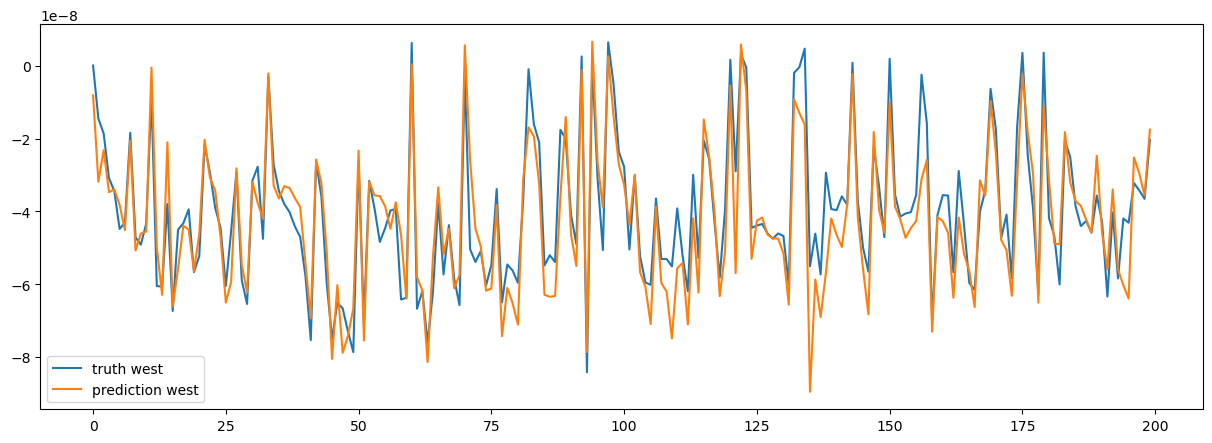

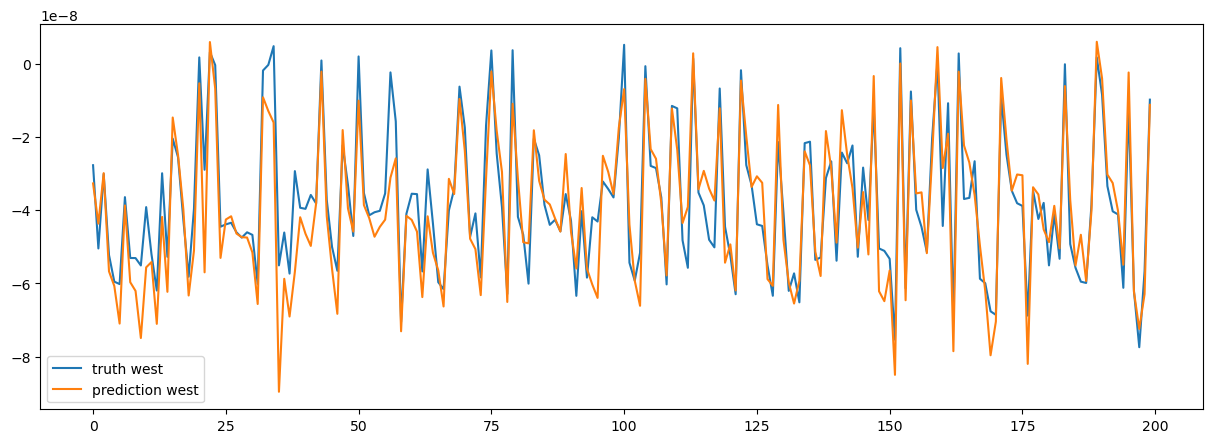

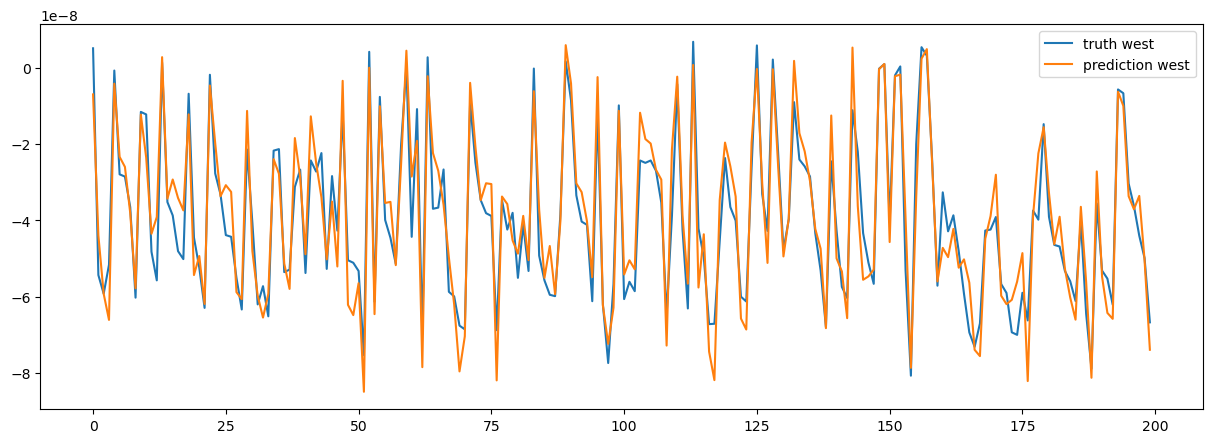

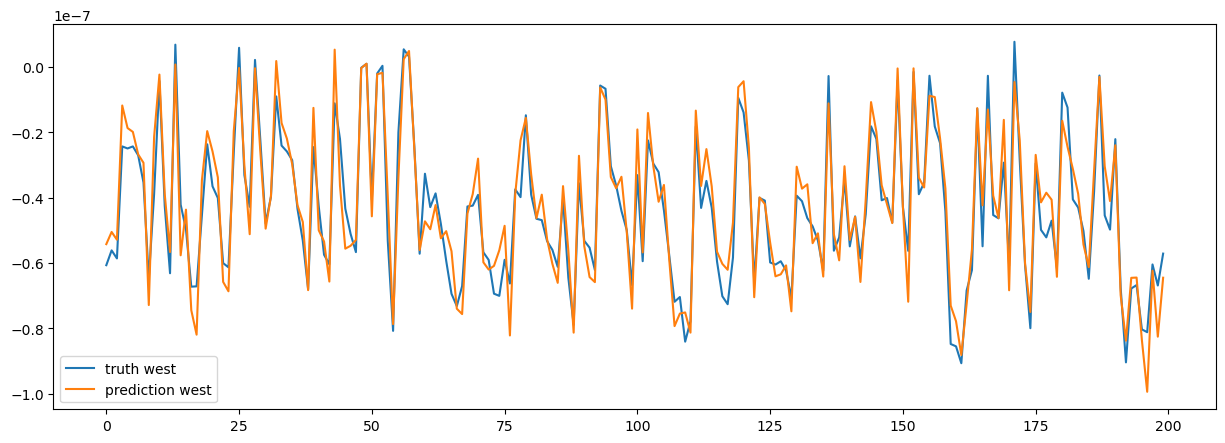

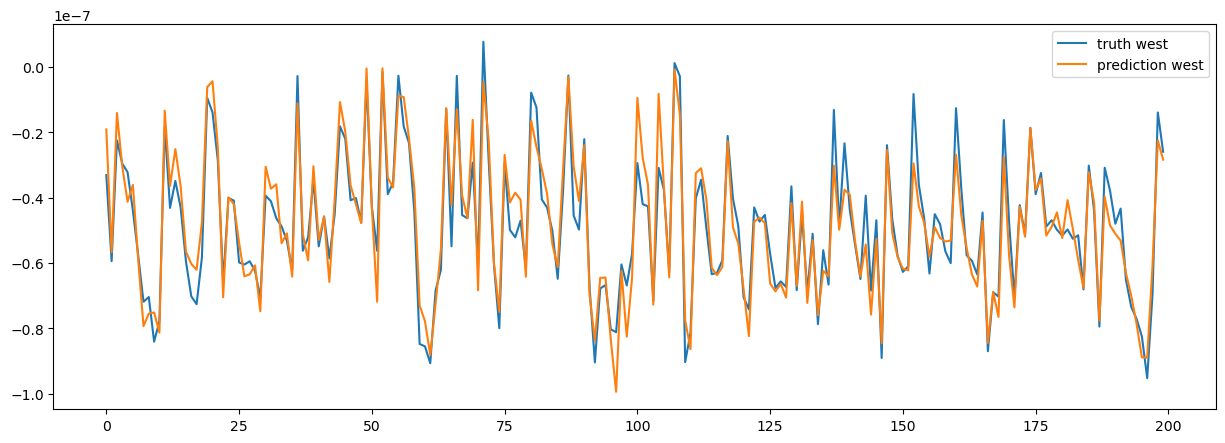

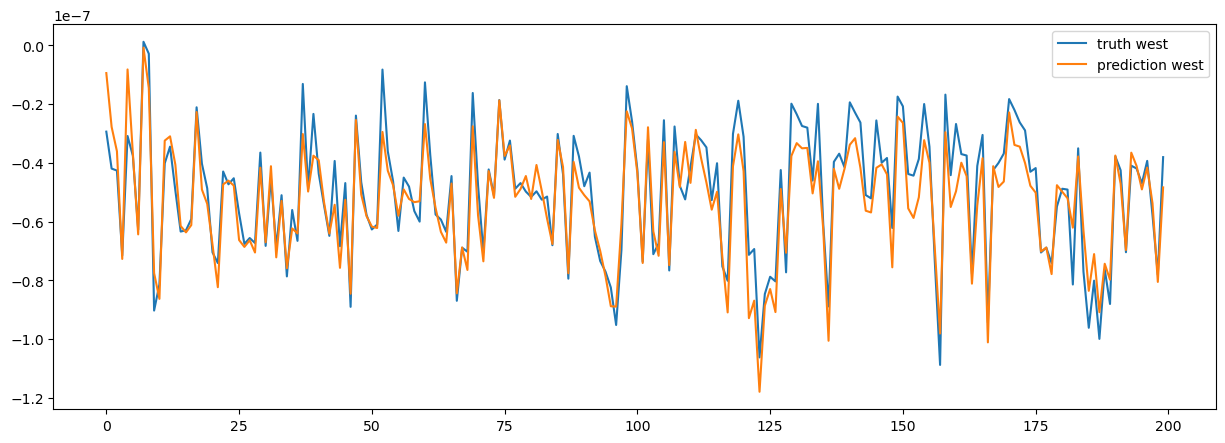

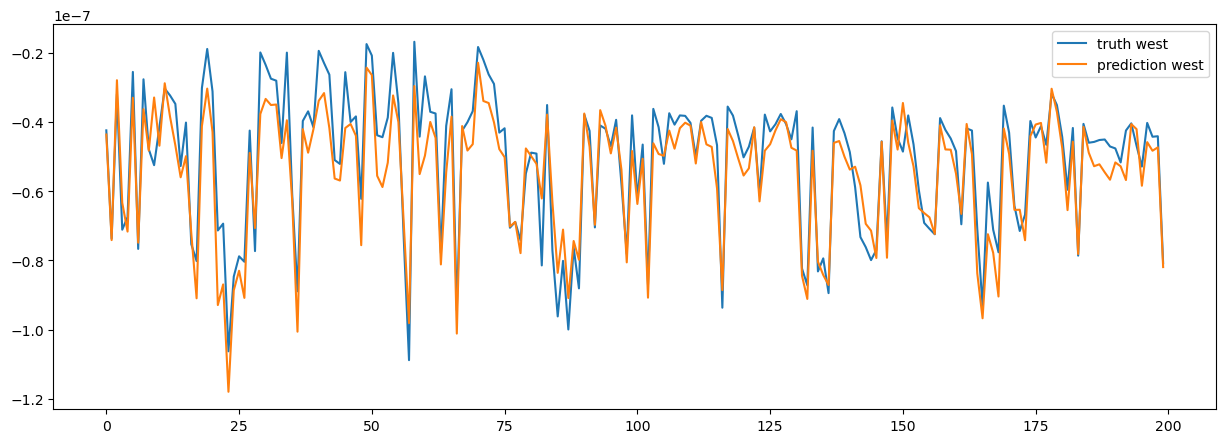

5.387966731793842e-09


In [ ]:
folder_name = 'boundary_condition'




model_name = 'num_classes-1_baselines-True_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-05_seed-42_date-Oct-11-2025'

#model_name = 'num_classes-4_baselines-False_size-50_decoder-conv_normalization-all_trainyear-2014_trainfreq-3_epochs-100_lr-5e-05_seed-42_date-Aug-06-2025_1'
inference_path=f"/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/{folder_name}/"

#data_save_name = f"{inference_path}{model_name}/{model_name}_best_predictions.npz"

data_save_name = f"{inference_path}{model_name}/{model_name}_final_epoch_data.pkl"
#'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025_final_epoch_data.pkl'

#data_dict = {'test_dataset_predictions':test_out,'test_dataset_truths':test_outputs}


with open(f'{data_save_name}', 'rb') as f:
    loaded_filtered_data_dict = pickle.load(f)

#loaded_filtered_data_dict = np.load(data_save_name)

predictions = loaded_filtered_data_dict['test_dataset_predictions']
truths = loaded_filtered_data_dict['test_dataset_truths']

'''
predictions = loaded_filtered_data_dict['train_dataset_predictions']
truths = loaded_filtered_data_dict['train_dataset_truths']
'''

checkpoint_to_load = get_checkpoint_to_load_updated(model_name,inference_path, prefer_best=True)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']
denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean
#print(denormalized_truths.min())
n=0
w=100
for n in range(8):
    start = n*100
    end = ((n+1)*100)+w   
    fig, ax = plt.subplots(1,1,figsize=(15,5))
    plt.plot(denormalized_truths[start:end],label = 'truth west')
    plt.plot(denormalized_predictions[start:end],label = 'prediction west')
    plt.legend()
    #plt.ylim(0, 1e-6)
    plt.show() 



mae = np.mean(np.abs(denormalized_truths - denormalized_predictions ))
print(mae)

In [6]:
data = {
    "truth": denormalized_truths,
    "predictions": denormalized_predictions
}

with open("truth_pred_data_full.pkl", "wb") as f:
    pickle.dump(data, f)


retrended_data = {
    "truth": retrended_denormalized_truths,
    "predictions": retrended_denormalized_predictions
}

with open("truth_pred_data_retrended_full.pkl", "wb") as f:
    pickle.dump(data, f)


NameError: name 'retrended_denormalized_truths' is not defined

loading checkpoint for num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025
Found best checkpoint: /user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/boundary_condition/num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025/num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025_best.pt
predictions shape (21989, 1)
4.918337544441762e-09


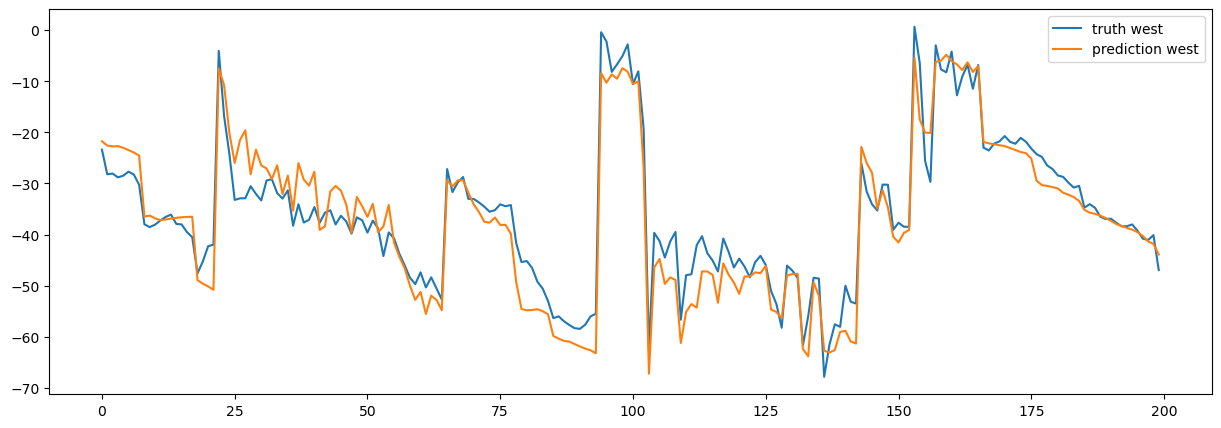

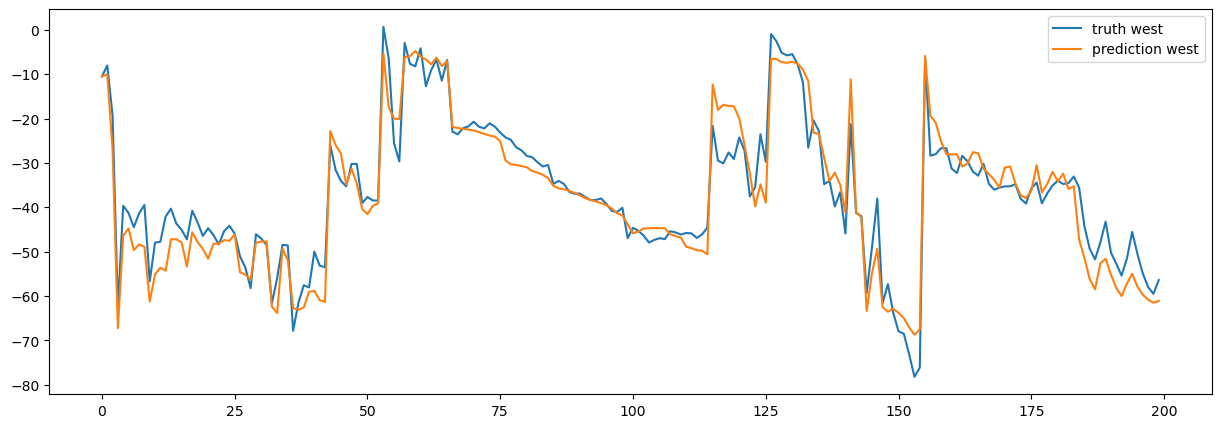

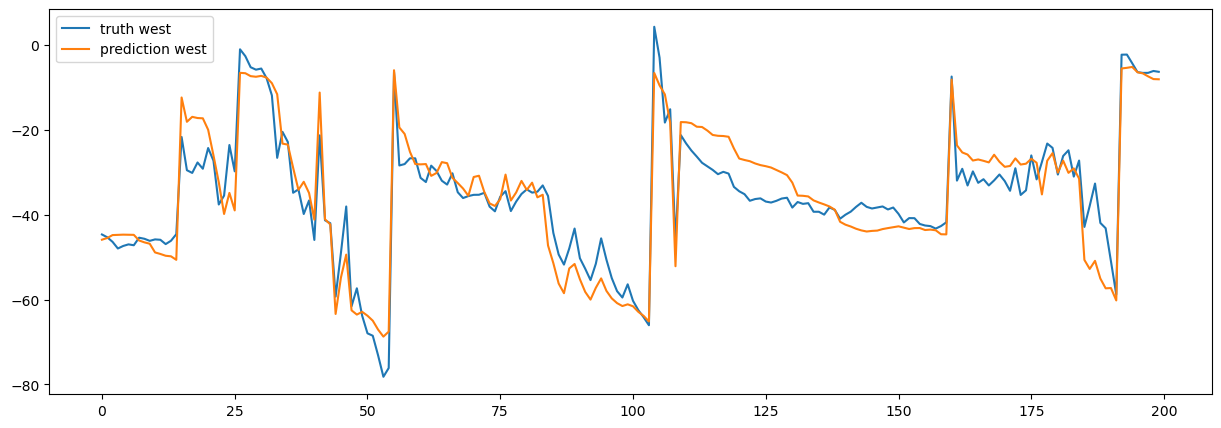

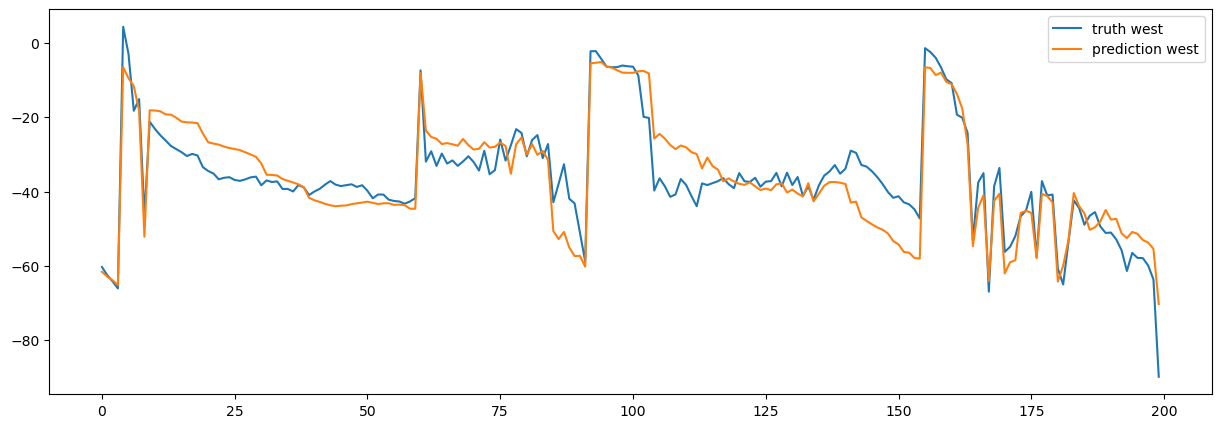

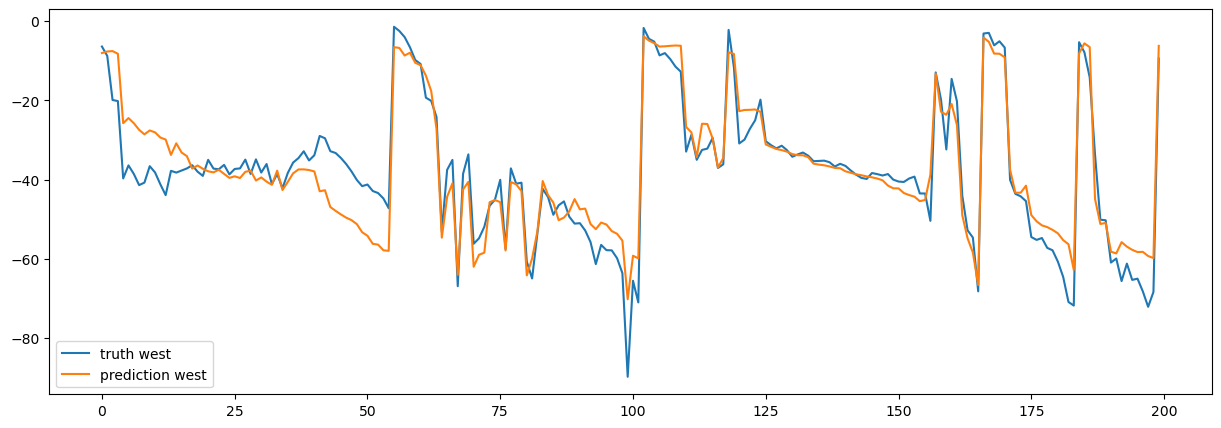

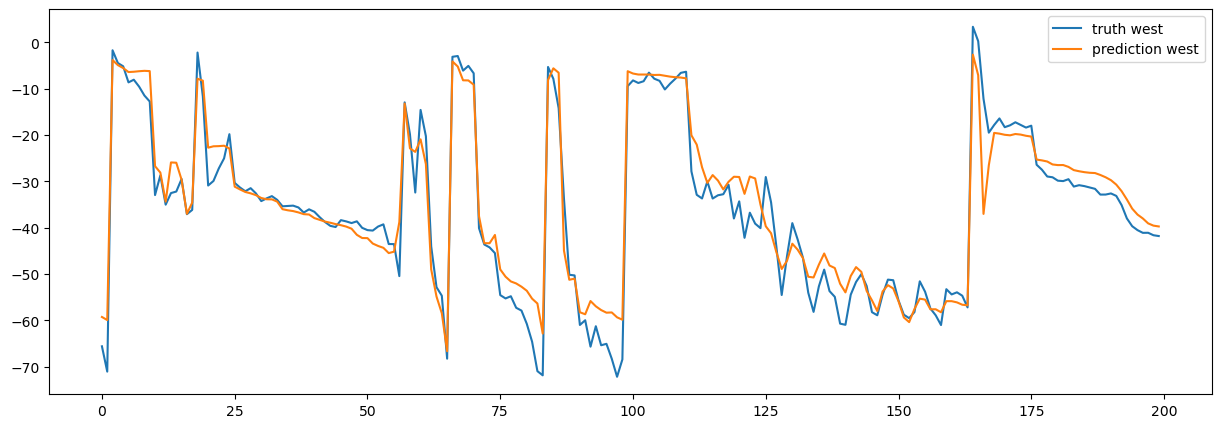

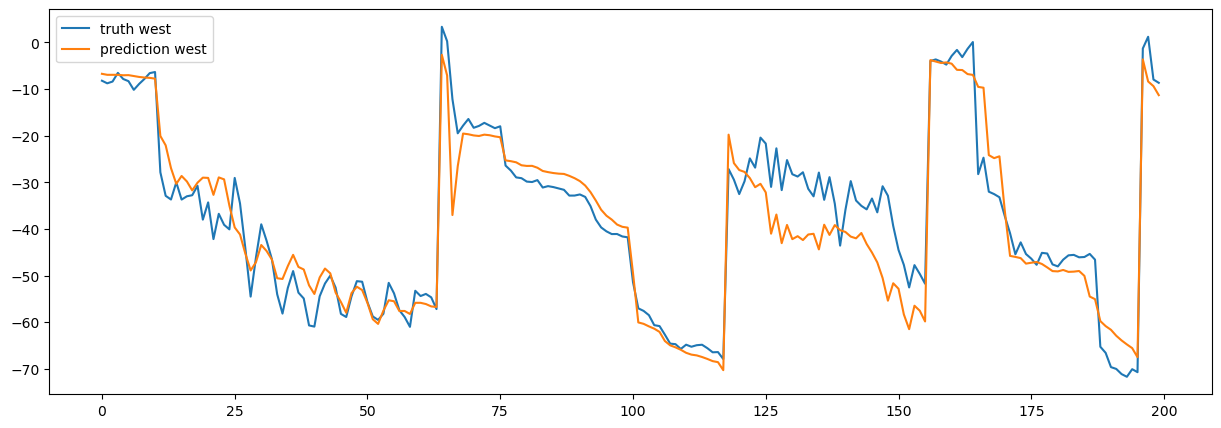

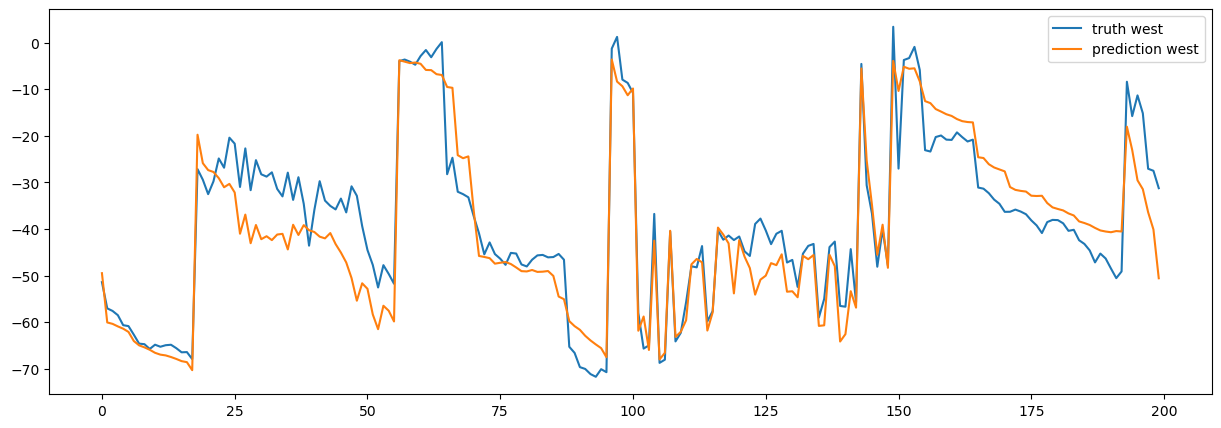

In [4]:
folder_name = 'boundary_condition'

'''
model_name = 'num_classes-1_baselines-True_size-50_format-sum_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-05_seed-42_date-Sep-26-2025'

model_name = 'num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-28_date-Nov-02-2025'
'''
model_name = 'num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025'
#model_name = 'num_classes-4_baselines-False_size-50_decoder-conv_normalization-all_trainyear-2014_trainfreq-3_epochs-100_lr-5e-05_seed-42_date-Aug-06-2025_1'
inference_path=f"/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/{folder_name}/"

#data_save_name = f"{inference_path}{model_name}/{model_name}_best_predictions.npz"

data_save_name = f"{inference_path}{model_name}/{model_name}_final_epoch_data.pkl"
#'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025_final_epoch_data.pkl'

#data_dict = {'test_dataset_predictions':test_out,'test_dataset_truths':test_outputs}


with open(f'{data_save_name}', 'rb') as f:
    loaded_filtered_data_dict = pickle.load(f)

#loaded_filtered_data_dict = np.load(data_save_name)
predictions = loaded_filtered_data_dict['test_dataset_predictions']
truths = loaded_filtered_data_dict['test_dataset_truths']

checkpoint_to_load = get_checkpoint_to_load_updated(model_name,inference_path, prefer_best=True)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']


denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean
print('predictions shape',denormalized_predictions.shape)
'''
denormalized_truths = (truths*output_std) +output_mean + test_correction_values
denormalized_predictions = (predictions*output_std) +output_mean + test_correction_values
'''

#print(denormalized_truths.min())
mae = np.mean(np.abs(denormalized_truths - denormalized_predictions ))
print(mae)

# Nawid - MAKE INTO PPB
denormalized_truths = denormalized_truths*1e9
denormalized_predictions = denormalized_predictions*1e9
n=0
w=100
for n in range(8):
    start = n*100
    end = ((n+1)*100)+w   
    fig, ax = plt.subplots(1,1,figsize=(15,5))
    plt.plot(denormalized_truths[start:end],label = 'truth west')
    plt.plot(denormalized_predictions[start:end],label = 'prediction west')
    plt.legend()
    #plt.ylim(0, 1e-6)
    plt.show() 





### Saving the data

In [6]:
# Replace with your actual file path
'''
with open("correction_values.pkl", "rb") as f:
    correction_values = pickle.load(f)
'''

with open("correction_values_full.pkl", "rb") as f:
    correction_values = pickle.load(f)

test_correction_values = correction_values['test_correction_values']
test_correction_values = test_correction_values.reshape(-1,1)
print(test_correction_values .shape)
# suppose your array is called arr
print("Max value:", np.nanmax(test_correction_values))       # safe max that ignores NaNs
print("Any NaNs present?:", np.isnan(test_correction_values).any())

(21989, 1)
Max value: 1.8168010937353404e-06
Any NaNs present?: False


In [ ]:
folder_name = 'boundary_condition'


model_name = 'num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025'
#model_name = 'num_classes-4_baselines-False_size-50_decoder-conv_normalization-all_trainyear-2014_trainfreq-3_epochs-100_lr-5e-05_seed-42_date-Aug-06-2025_1'
inference_path=f"/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/{folder_name}/"

#data_save_name = f"{inference_path}{model_name}/{model_name}_best_predictions.npz"

data_save_name = f"{inference_path}{model_name}/{model_name}_final_epoch_data.pkl"
#'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025_final_epoch_data.pkl'

#data_dict = {'test_dataset_predictions':test_out,'test_dataset_truths':test_outputs}


with open(f'{data_save_name}', 'rb') as f:
    loaded_filtered_data_dict = pickle.load(f)

#loaded_filtered_data_dict = np.load(data_save_name)
predictions = loaded_filtered_data_dict['test_dataset_predictions']
truths = loaded_filtered_data_dict['test_dataset_truths']

checkpoint_to_load = get_checkpoint_to_load_updated(model_name,inference_path, prefer_best=True)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']


denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean
print('predictions shape',denormalized_predictions.shape)

retrended_denormalized_truths = (truths*output_std) +output_mean + test_correction_values
retrended_denormalized_predictions = (predictions*output_std) +output_mean + test_correction_values


loading checkpoint for num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025
Found best checkpoint: /user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/boundary_condition/num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025/num_classes-1_baselines-True_auxililary-multiple_size-50_format-corrected_decoder-conv_normalization-all_trainyear-2014-6_trainfreq-3_epochs-200_lr-5e-06_seed-31_date-Nov-28-2025_best.pt
predictions shape (21989, 1)


In [ ]:
data = {
    "truth": denormalized_truths,
    "predictions": denormalized_predictions
}

with open("truth_pred_data_full_2016.pkl", "wb") as f:
    pickle.dump(data, f)


retrended_data = {
    "truth": retrended_denormalized_truths,
    "predictions": retrended_denormalized_predictions
}

with open("truth_pred_data_2016_retrended_full.pkl", "wb") as f:
    pickle.dump(data, f)


In [9]:
# Getting the data in the correct format
## Lat- lon and the detrending
ds = xr.open_dataset("test_subset_full.nc")
with open('truth_pred_data_full.pkl', 'rb') as file:
    data = pickle.load(file)


ds = ds.assign({'true_bc_detrended': (('time'), 1e9*data["truth"].flatten())})
ds = ds.assign({'pred_bc_detrended': (('time'), 1e9*data["predictions"].flatten())})
attrs = {"units":"ppb", "domain": "SOUTHAMERICA", "model_name":"example_name", "parameter_file":"parameter_file", "created_on":str(datetime.now()), "created_by":"Nawid Keshtmand"}
ds = ds.assign_attrs(attrs)
# Contains the full dataset (including truths and preddictions)
ds.to_netcdf("test_dataset_truth_pred_full.nc")

In [10]:
loaded_ds = xr.open_dataset("test_dataset_truth_pred_full.nc")

In [24]:
loaded_ds

<xarray.Dataset>
Dimensions:            (time: 21989, lat: 357, lon: 190)
Coordinates:
  * time               (time) datetime64[ns] 2017-01-01T15:01:57 ... 2017-12-...
  * lat                (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon        (time) float32 ...
    release_lat        (time) float32 ...
    true_bc_detrended  (time) float64 ...
    pred_bc_detrended  (time) float64 ...
Attributes:
    max_level:       17
    author:          rt17603
    created:         2019-05-06 23:39:16.891007
    units:           ppb
    domain:          SOUTHAMERICA
    model_name:      example_name
    parameter_file:  parameter_file
    created_on:      2026-01-13 14:04:46.001540
    created_by:      Nawid Keshtmand

# Error Analysis

## Loading footprint data

In [4]:
from model.data.load_data import *
parameters = {
    "model_name" : "test_run",
    "train_load_data" : {
       "year":"201[4-6]",
        "freq":3,
        "region":"BRAZIL",
        "verbose":True,
        "size":50,
    },

    "test_load_data" : {
        "year":"2017",
        "freq":1
    },

    "variables" : {
        "met_variables":{"x_wind":[3,9,15,21,30,42,51], "wind_speed":[3,30,51], "wind_angle":[3,30,51], "y_wind":[3,9,15,21,30,42,51], "upward_air_velocity":[3,9,15,21,30,42,51], "air_temperature":[3,9,15,21,30,42,51], "air_pressure":[3,9,15,21,30,42,51], "atmosphere_boundary_layer_thickness":[], "surface_air_pressure":[]},
        #"met_variables":{"x_wind":[3,9,15,21,30,42,51], "wind_speed":[3,30,51], "wind_angle":[3,30,51], "y_wind":[3,9,15,21,30,42,51], "upward_air_velocity":[3,9,15,21,30,42,51], "air_temperature":[3,9,15,21,30,42,51], "air_pressure":[3,9,15,21,30,42,51], "atmosphere_boundary_layer_thickness":[], "surface_air_pressure":[]},
        "static_variables":["sin_lat_coords", "sin_lon_coords", "cos_lat_coords", "cos_lon_coords", "lat_coords", "lon_coords", "x_coords", "y_coords", "topog",'normalised_time_of_year','normalised_day_of_year'],
        "time_deltas":[6,12]
    },

    "dataloader_parameters":{
        "input_transforms":["clever_transform_3"],
    },

    "model_parameters":{
        "num_blocks":4, 
        "node_dim":64, 
        "edge_dim":64, 
        "hidden_layers_processor_node":2, 
        "hidden_layers_processor_edge":2,  
        "hidden_layers_decoder":1, 
        "hidden_dim_processor_node":16, 
        "hidden_dim_processor_edge":16, 
        "hidden_dim_decoder":16, 
        "resolution":4, 
        "output_dim":8, 
        "residuals":False, 
        "attention":False
    },
    'normalization':'all',
    "learning_rate":5e-6,
    "seed":42,
    "epochs":200,
    "num_classes":1,
    "use_baselines":True,
    'network_decoder':'conv',
    'output_format':'corrected',
    'auxiliary':'multiple',

    "loss_functions" : {
        "criterion": "torch.nn.MSELoss()",
        "criterion_test": "torch.nn.MSELoss()"
    }    
}

train_load_data = copy.deepcopy(parameters["train_load_data"])
# load train parameters and upload with any changes to test data
test_load_data = copy.deepcopy(parameters["train_load_data"])
test_load_data.update(parameters["test_load_data"])
# Nawid - Making it so that the different value can be used for the case where there is a single value for the approach
print(train_load_data)
print(test_load_data)
    
#data = LoadSquareSatelliteFp(**train_load_data)
test_data = LoadSquareSatelliteFp(**test_load_data) 

{'year': '201[4-6]', 'freq': 3, 'region': 'BRAZIL', 'verbose': True, 'size': 50}
{'year': '2017', 'freq': 1, 'region': 'BRAZIL', 'verbose': True, 'size': 50}
---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2017*.nc
footprints loaded
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 22345 footprints
----- Cutting footprints to square of size 50
for 356 footprints, a square of size x size escapes the footprint domain in directions {'N': 0, 'S': 0, 'E': 356, 'W': 0}. 
 dropping these! if you want to keep them anyway, pass delete_outofdomain=False
---- All done!


In [ ]:
test_data.fp_data.shape
np.save("test_fp_data.npy", test_data.fp_data)
fp_data = np.load("test_fp_data.npy")



In [25]:
k = 10  # number of plots you want

# Step 1: flatten error to shape (n,)
err = error.squeeze()

# Step 2: get indices of the top-k largest errors
top_k_indices = np.argsort(err)[:k] # Lowest Error

#top_k_indices = np.argsort(err)[-k:][::-1]  # Highest error

# Step 3: extract fp_data rows
top_k_data = fp_data[top_k_indices]

# Step 4 & 5: reshape and plot
plt.figure(figsize=(12, 3 * k))

for i, idx in enumerate(top_k_indices):
    reshaped = top_k_data[i].reshape(50, 50)  # last dim 1 is not needed for plotting
    reshaped = np.log10(reshaped)
    plt.subplot(k, 1, i + 1)
    plt.imshow(reshaped, cmap="viridis")
    plt.colorbar()
    plt.title(f"Index {idx} — Error = {err[idx]:.4f}")

plt.tight_layout()
plt.show()

NameError: name 'fp_data' is not defined

## Spaatial error analysis

In [11]:
def plot_seasonal_density_histogram(ds, degree_bins=2, vmin_vmax=None):
    """
    Plot density histograms of release locations, as four panels in a row, one for each season.
    Parameters:
    ds: xarray.Dataset containing 'release_lon', 'release_lat', 'time', 'lat' and 'lon' variables
    degree_bins: size of the latitude/longitude bins in degrees
    vmin_vmax: color scale limits for the histograms, as a list [vmin, vmax] e.g. [0, 10]
    """
    release_lons = ds.release_lon.values
    release_lats = ds.release_lat.values

    dom_lons = ds.lon.values
    dom_lats = ds.lat.values

    dates = pd.DatetimeIndex(ds.time)

    seasons = {"JFM":["01", "02", "03"], "AMJ":["04", "05", "06"], "JAS":["07", "08", "09"], "OND":["10", "11", "12"]}


    # create the bins for the data
    lat_bins = range(int(np.floor(release_lats.min())- degree_bins/2), int(np.ceil(release_lats.max())+ degree_bins/2) + 1, degree_bins) 
    lon_bins = range(int(np.floor(release_lons.min())- degree_bins/2), int(np.ceil(release_lons.max())+ degree_bins/2) + 1, degree_bins) 

    # set up the figure and axis
    fig = plt.figure(figsize=(12,5),  dpi=400, constrained_layout=True)
    gs = fig.add_gridspec(1, 5, figure=fig, width_ratios=[1, 1, 1,1,0.05])

    ax = np.empty((1, 4), dtype=object)

    for i in range(1):  
        for j in range(4):
            ax[i, j] = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) 


    for season_n, seas in enumerate(seasons.keys()):
        #season_results[seas] = {"mean_mfs":mean_mfs, "mean_mfs_emulated":mean_mfs_emulated}
        seasonal_idxs = np.where(np.bitwise_and(dates.month>=int(seasons[seas][0]), dates.month<=int(seasons[seas][-1])))[0]
        print(season_n, seas)

        # extract 2D-bins
        binned_fps,  lat_edges, lon_edges, binnumber = binned_statistic_2d(
                release_lats[seasonal_idxs],
                release_lons[seasonal_idxs],
                None,
                bins=[lat_bins, lon_bins],
                statistic='count',
                expand_binnumbers=True
                )
        
        binned_fps[binned_fps==0] = np.nan

        cbar = True if season_n == 3 else False

        ax[0, season_n], cbar_hist = plot_binned_map(ax[0, season_n], lon_edges, lat_edges, binned_fps, cut_lats=(40,20), cmap="Greens", metric_name="Observation count", vmin_vmax=vmin_vmax, fig=fig, cbar=cbar, cbar_position="right", title_str=seas, return_cbar=True, domain_lats=dom_lats, domain_lons=dom_lons)


def plot_binned_map(ax, binned_lons, binned_lats, metric, metric_name = "", extent="default", cut_lats=[0,0], title_str="", bin=False, domain_lats=None, domain_lons=None, divergent=False, vmin_vmax = None, cmap="metrics", fig=None, cbar=True, cbar_position="bottom", title_loc="top", return_cbar=False):
    
    
    if domain_lats is None:
        print("need domain lats!")
    if domain_lons is None:
        print("need domain lons!")

    extent = (domain_lons[0], domain_lons[-1], domain_lats[cut_lats[0]], domain_lats[-1-cut_lats[1]])
    ax.set_extent(extent, crs=cartopy.crs.PlateCarree())


    higher_or_lower = {"IoU":"Higher", 'MSE':"Lower", "Corr Coeff": "Higher", "Log CorrCoeff": "Higher"}

    if cmap == "metrics":
        if metric_name in higher_or_lower.keys():
            if higher_or_lower[metric_name] == "Higher": 
                cmap="autumn"
            if higher_or_lower[metric_name] == "Lower": 
                cmap="autumn_r"
        else:
            cmap="autumn"
    """ 
        if metric_name== "IoU":
            cmap="Reds_r"
            cmap="autumn"
        else:
            cmap = "Reds"
            cmap="autumn_r"
    """

    if vmin_vmax is None:
        print("calculating vmin and vmax from data")
        vmin_vmax = [np.nanmin(metric), np.nanmax(metric)]
        
    
    if divergent:
        norm = TwoSlopeNorm(vmin=vmin_vmax[0], vcenter=0, vmax=vmin_vmax[1])
        cmap="PiYG"
    else:
        norm = Normalize(vmin=vmin_vmax[0], vmax=vmin_vmax[1])

    im = ax.pcolormesh(binned_lons, binned_lats, metric, transform=ccrs.PlateCarree(),cmap=cmap, norm=norm) 

    if title_loc=="top":    
        ax.set_title(title_str)
    if title_loc=="left":
        coord = -0.1
        if "\n" in title_str:
            coord = -0.2
        ax.text(coord, 0.5, title_str,  
              va="center", ha="center",  
              rotation="vertical", fontsize=15,  
              transform=ax.transAxes, multialignment="center")



    if cbar:
        assert fig is not None, "fig cant be empty if you want a cbar in this axis!"
        
        if metric_name in higher_or_lower.keys():
            cbar_label = f"{metric_name} \n {higher_or_lower[metric_name]} is better"
        else:
            cbar_label = f"{metric_name}" 

        if cbar_position == "bottom":
            cbar = fig.colorbar(im, ax=ax, orientation="horizontal", extend='both', shrink=0.7).set_label(cbar_label)
        if cbar_position == "right":
            if metric_name is None: cbar_label = "ppb"
            cbar = fig.colorbar(im, ax=ax, orientation="vertical", extend='both', shrink=0.7).set_label(cbar_label)

    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS,linewidth=1.)
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)

    if return_cbar:
        return ax, im
    else:
        return ax

In [11]:
train_subset = xr.open_dataset("train_subset.nc")
print(train_subset)

#plot_seasonal_density_histogram(train_subset)

<xarray.Dataset>
Dimensions:      (time: 18281, lat: 357, lon: 190)
Coordinates:
  * time         (time) datetime64[ns] 2014-01-01T16:04:56.500000 ... 2016-12...
  * lat          (lat) float32 -60.98 -60.75 -60.51 -60.28 ... 21.85 22.09 22.32
  * lon          (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon  (time) float32 ...
    release_lat  (time) float32 ...
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-14 13:21:46.638679


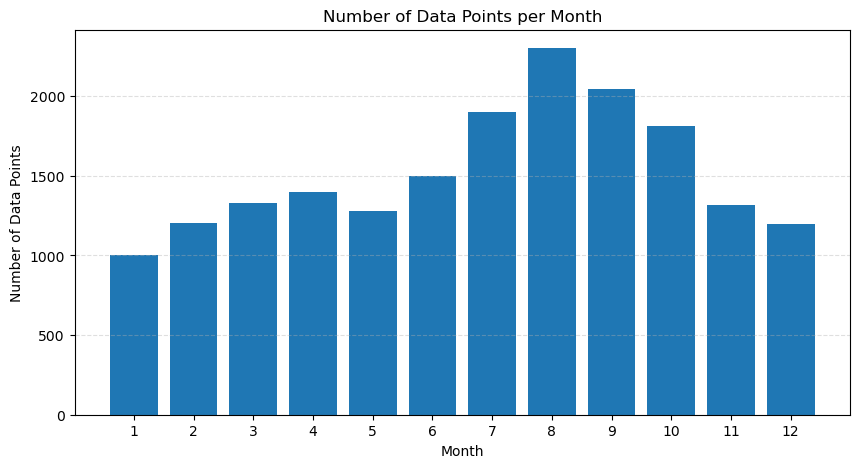

In [12]:
import numpy as np

months = train_subset.time.dt.month.values
# months is an array like [1, 1, 1, 2, 2, 3, ...]

monthly_counts = np.bincount(months, minlength=13)[1:]  # skip index 0

plt.figure(figsize=(10,5))
plt.bar(range(1,13), monthly_counts)
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Number of Data Points")
plt.title("Number of Data Points per Month")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

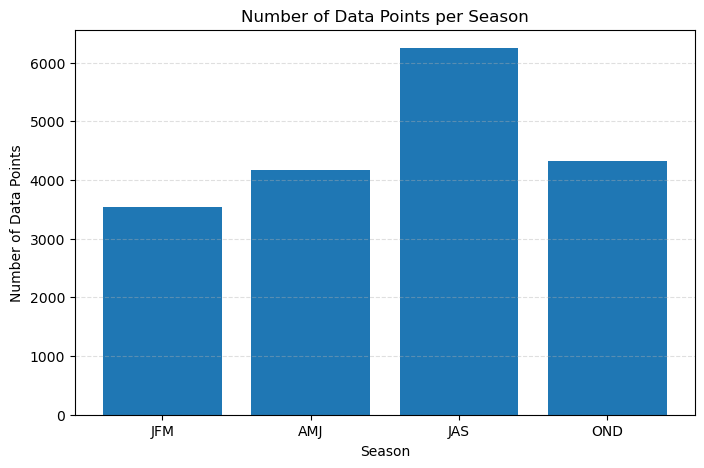

In [13]:
season_labels = {
    "JFM": [1,2,3],
    "AMJ": [4,5,6],
    "JAS": [7,8,9],
    "OND": [10,11,12]
}

season_counts = {
    season: np.isin(months, month_list).sum()
    for season, month_list in season_labels.items()
}

plt.figure(figsize=(8,5))
plt.bar(season_counts.keys(), season_counts.values())
plt.xlabel("Season")
plt.ylabel("Number of Data Points")
plt.title("Number of Data Points per Season")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [14]:
# Load up the map
# Look at the difference bbetween the truth and the predicitons
# Plot this on the map

#denormalized_truths
#denormalized_predictions
ds_subset = xr.open_dataset("test_subset_full.nc")
print(ds_subset)

<xarray.Dataset>
Dimensions:      (time: 21989, lat: 357, lon: 190)
Coordinates:
  * time         (time) datetime64[ns] 2017-01-01T15:01:57 ... 2017-12-31T17:...
  * lat          (lat) float32 -60.98 -60.75 -60.51 -60.28 ... 21.85 22.09 22.32
  * lon          (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon  (time) float32 ...
    release_lat  (time) float32 ...
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-06 23:39:16.891007


In [17]:
import numpy as np

#error = denormalized_predictions - denormalized_truths
# or absolute error:
error = np.abs(denormalized_predictions - denormalized_truths)
rmse = np.sqrt(np.mean(error**2))
print("RMSE:", rmse)

RMSE: 6.3397610601518685e-09


In [15]:
data_to_save = {
    "truth": denormalized_truths,
    "predictions": denormalized_predictions,
}

with open("truth_pred_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

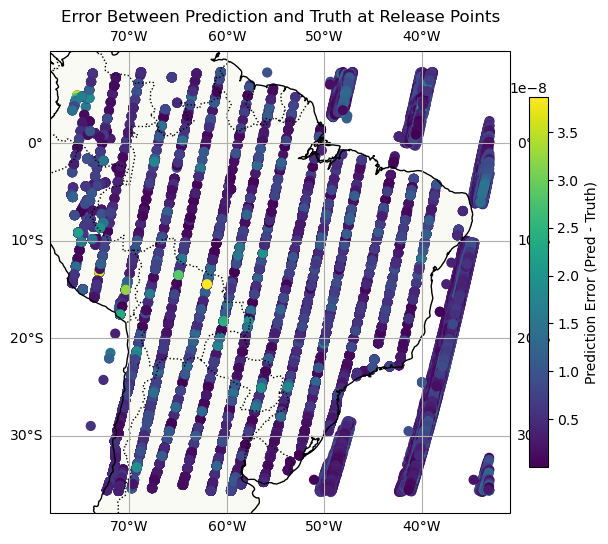

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract lat/lon from dataset and convert to numpy
lats = ds_subset["release_lat"].values
lons = ds_subset["release_lon"].values

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.gridlines(draw_labels=True)

# Scatter plot: colorized by error magnitude
plot = ax.scatter(
    lons,
    lats,
    c=error,
    s=40,
    cmap="viridis",    # blue = negative error, red = positive error
    transform=ccrs.PlateCarree(),
)

# Add colorbar
cbar = plt.colorbar(plot, orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("Prediction Error (Pred - Truth)")

plt.title("Error Between Prediction and Truth at Release Points")
plt.show()

## Seasonal


(2201, 1)

In [12]:
squared_error = (denormalized_predictions - denormalized_truths)**2

# Assign both errors to the dataset
ds_err = ds_subset.assign(
    error=("time", error.flatten()),
    sq_error=("time", squared_error.flatten())
)

# Monthly mean absolute error (original)
monthly_error = ds_err["error"].groupby("time.month").mean()

# Monthly RMSE
monthly_rmse = np.sqrt(ds_err["sq_error"].groupby("time.month").mean())

# Define seasons
group_labels = ["Q1 (Jan–Mar)", "Q2 (Apr–Jun)", "Q3 (Jul–Sep)", "Q4 (Oct–Dec)"]
month_groups = {
    "Q1 (Jan–Mar)": [1, 2, 3],
    "Q2 (Apr–Jun)": [4, 5, 6],
    "Q3 (Jul–Sep)": [7, 8, 9],
    "Q4 (Oct–Dec)": [10, 11, 12],
}

# Seasonal mean absolute error
seasonal_error = {
    label: monthly_error.sel(month=months).mean().item()
    for label, months in month_groups.items()
}

# Seasonal RMSE
seasonal_rmse = {
    label: np.sqrt((monthly_rmse.sel(month=months)**2).mean().item())
    for label, months in month_groups.items()
}

# Print results
print("Monthly Mean Absolute Error:")
print(monthly_error)

print("\nMonthly RMSE:")
print(monthly_rmse)

print("\nSeasonal Mean Absolute Error:")
print(seasonal_error)

print("\nSeasonal RMSE:")
print(seasonal_rmse)

NameError: name 'ds_subset' is not defined

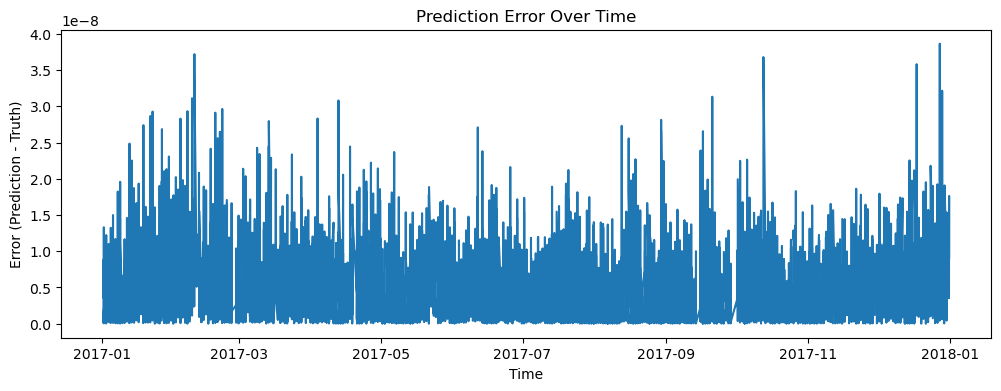

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ds_err["time"], ds_err["error"])
plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Prediction - Truth)")
plt.show()

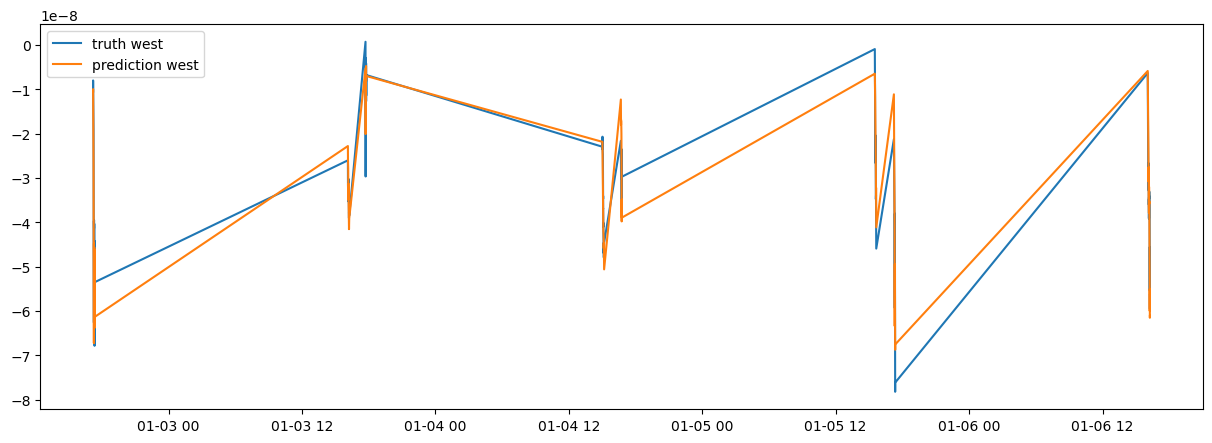

In [34]:
import matplotlib.pyplot as plt

# Assuming:
#   ds_subset["time"] is your time coordinate (xarray DataArray)
#   denormalized_truths and denormalized_predictions are numpy arrays with shape (time, ...)
#   For plotting, we collapse spatial dims if needed.

N = 200   # change this to 200, etc.


# If your arrays are >1D (e.g., (time, 1, 1)), flatten them:
truth = denormalized_truths.flatten()
pred  = denormalized_predictions.flatten()
'''
plt.figure(figsize=(12,5))
plt.plot(ds_subset["time"], truth, label="Ground Truth", linewidth=2)
plt.plot(ds_subset["time"], pred, label="Prediction", linestyle="--")
plt.title("Ground Truth vs Prediction Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
'''
'''
plt.figure(figsize=(12,5))
plt.plot(ds_subset["time"][:N], truth[:N], label="Ground Truth", linewidth=2)
plt.plot(ds_subset["time"][:N], pred[:N], label="Prediction", linestyle="--")
plt.title(f"Ground Truth vs Prediction (First {N} time steps)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
'''

start = 1*100
end = ((1+1)*100)+100   
fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(ds_subset["time"][start:end],denormalized_truths[start:end],label = 'truth west')
plt.plot(ds_subset["time"][start:end],denormalized_predictions[start:end],label = 'prediction west')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show()


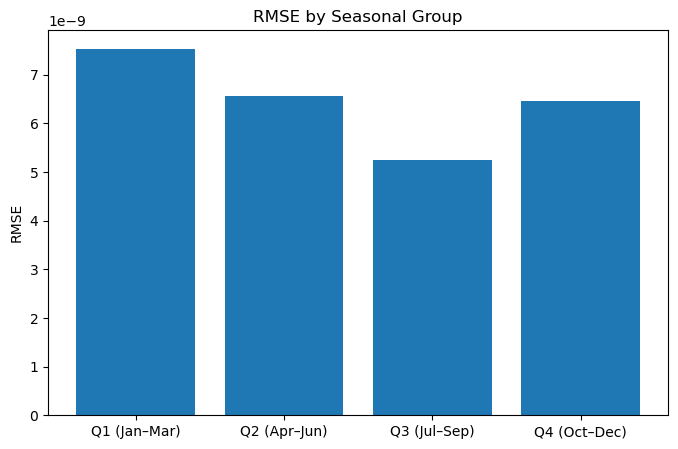

In [35]:
'''
plt.figure(figsize=(8,5))
plt.bar(seasonal_error.keys(), seasonal_error.values())
plt.title("Average Prediction Error by Seasonal Group")
plt.ylabel("Mean Error")
plt.show()
'''
plt.figure(figsize=(8,5))
plt.bar(seasonal_rmse.keys(), seasonal_rmse.values())
plt.title("RMSE by Seasonal Group")
plt.ylabel("RMSE")
plt.show()

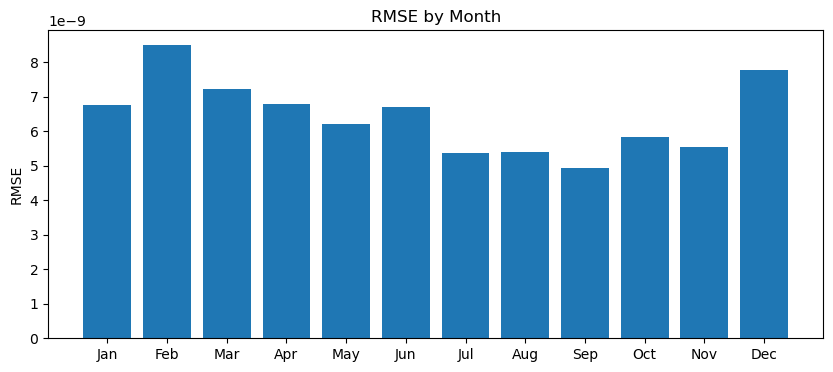

In [24]:
'''
plt.figure(figsize=(10,4))
plt.bar(monthly_error["month"], monthly_error.values)
plt.xticks(ticks=range(1,13), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.title("Average Prediction Error by Month")
plt.ylabel("Mean Error")
plt.show()
'''
plt.figure(figsize=(10,4))
plt.bar(monthly_rmse["month"], monthly_rmse.values)
plt.xticks(ticks=range(1,13), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.title("RMSE by Month")
plt.ylabel("RMSE")
plt.show()

### Spatial temporal plots

In [24]:
from metrics_and_figures import *

['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/', '/user/work/yl18410/new_graphnet', '/user/work/ef17148/oldstuff/ef1714

In [26]:
domain_lats = ds_subset['lat'].values
domain_lons = ds_subset['lon'].values

all_mses shape: (21989,)
true_fps shape: (21989, 1)
predictions shape: (21989, 1)
Season: JFM  | len(mses): 4593  | len(lats): 4593  | len(lons): 4593
Season: AMJ  | len(mses): 5233  | len(lats): 5233  | len(lons): 5233
Season: JAS  | len(mses): 7069  | len(lats): 7069  | len(lons): 7069
Season: OND  | len(mses): 5094  | len(lats): 5094  | len(lons): 5094
vmin_vmax: {'mses_binned': [0, 1000]}


/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/events.py:93: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


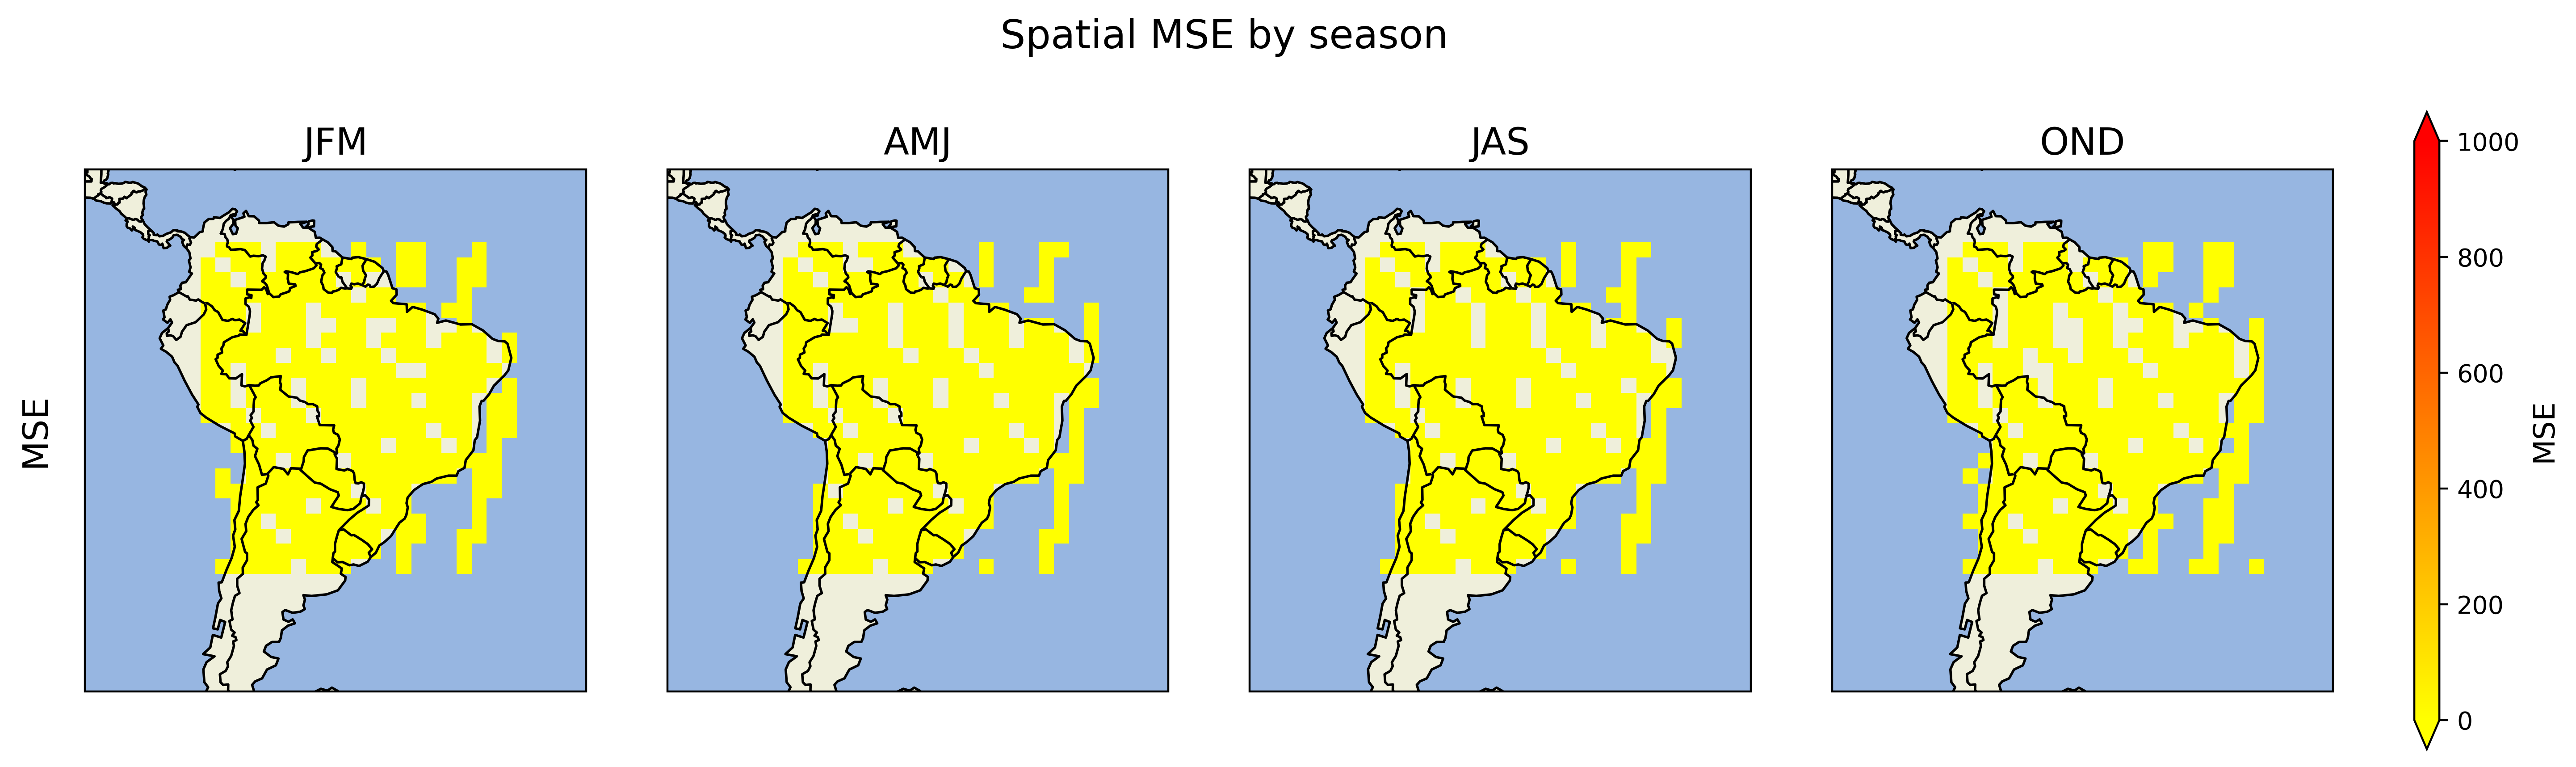

In [27]:
dates = ds_subset['time']
season_results = get_binned_seasonal_scores(denormalized_truths, denormalized_predictions, dates, lats , lons, degree_bins=2)
#plot_massive_binned_map_mse_auto(season_results, domain_lats, domain_lons)
'''
vmin_vmax_default = {"mses_binned": [0, 5e-16]}
plot_massive_binned_map_mse_only(season_results, domain_lats, domain_lons,vmin_vmax=vmin_vmax_default)
'''
vmin_vmax_default = {"mses_binned": [0, 1000]}
plot_massive_binned_map_mse_only(season_results, domain_lats, domain_lons,vmin_vmax=vmin_vmax_default)

JFM | 4593 points
AMJ | 5233 points
JAS | 7069 points
OND | 5094 points


/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/events.py:93: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


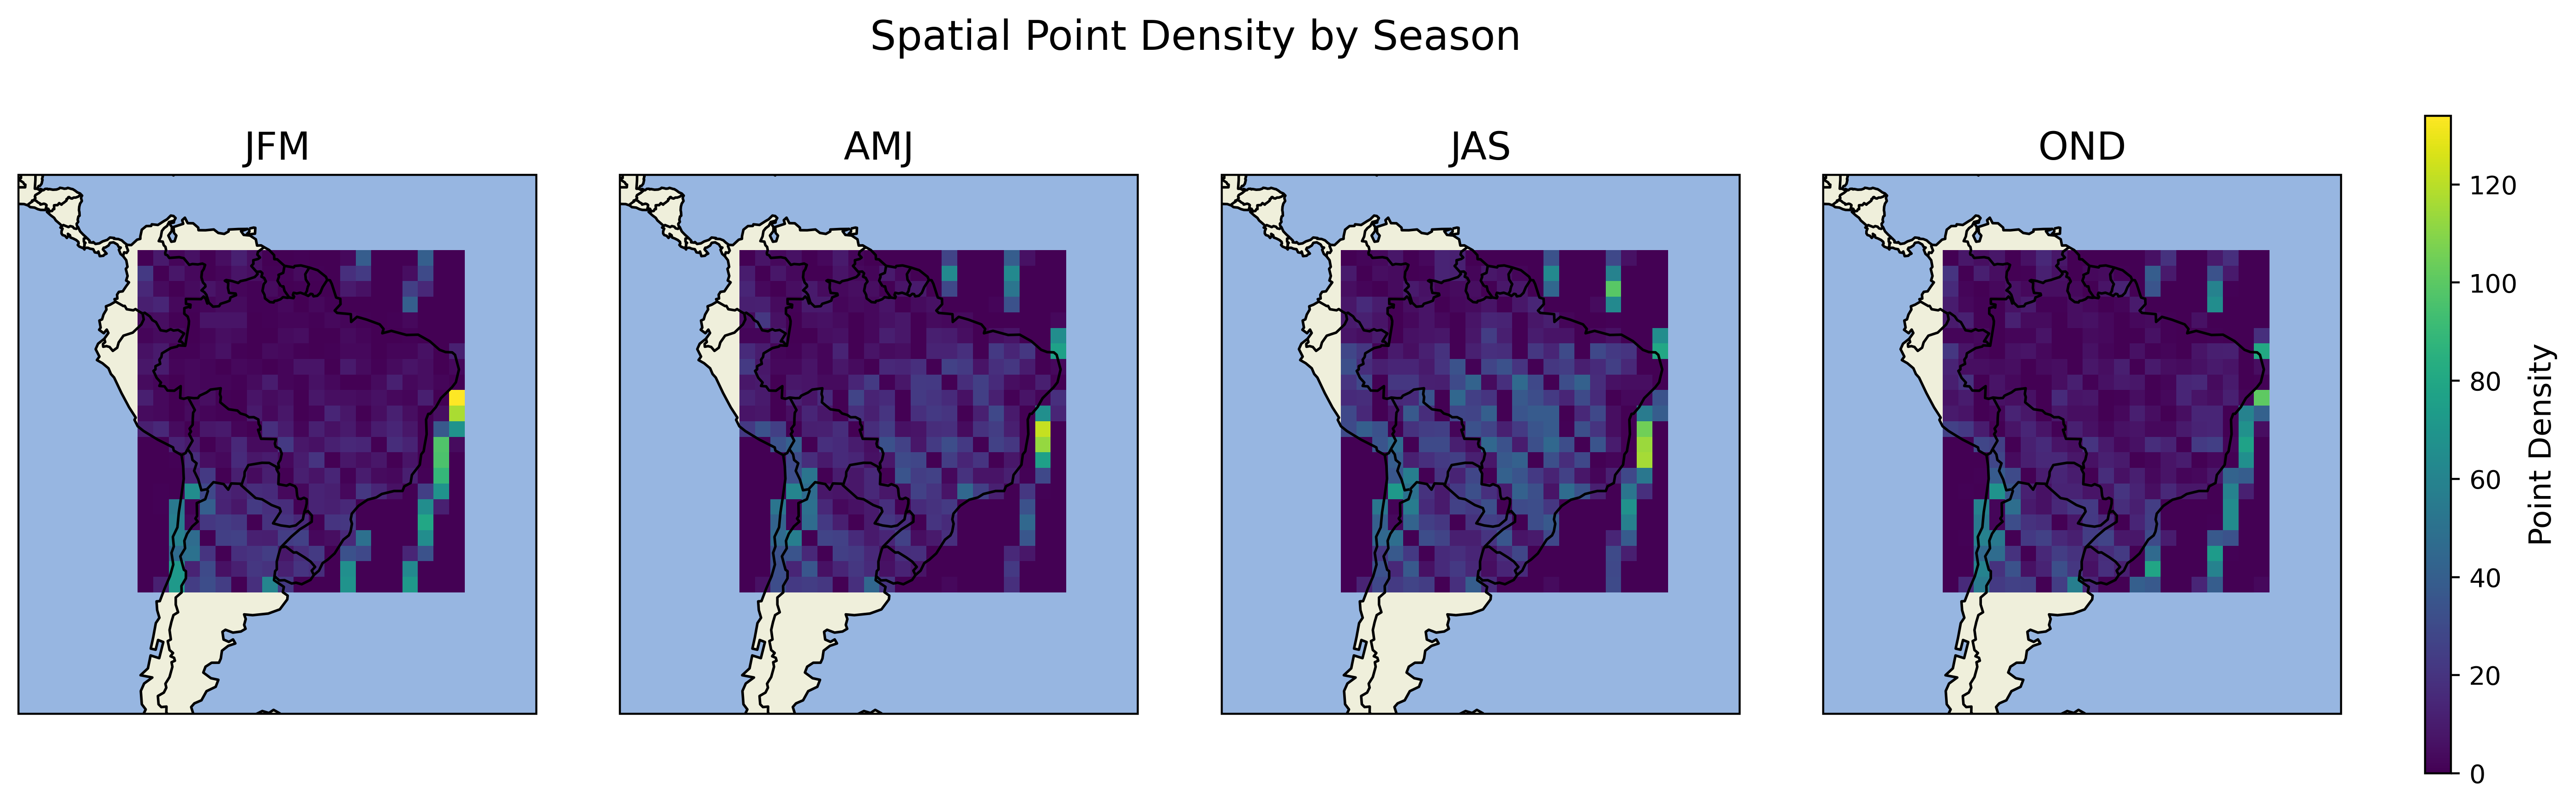

In [40]:
season_results = get_binned_seasonal_density(
    dates=ds_subset.time,
    release_lats=ds_subset.release_lat.values,
    release_lons=ds_subset.release_lon.values,
    degree_bins=2
)

plot_massive_binned_map_density_only(
    season_results,
    domain_lats=ds_subset.lat.values,
    domain_lons=ds_subset.lon.values
)

## Seasonal including the different values

/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/metrics_and_figures.py:1521: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  
/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/events.py:93: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


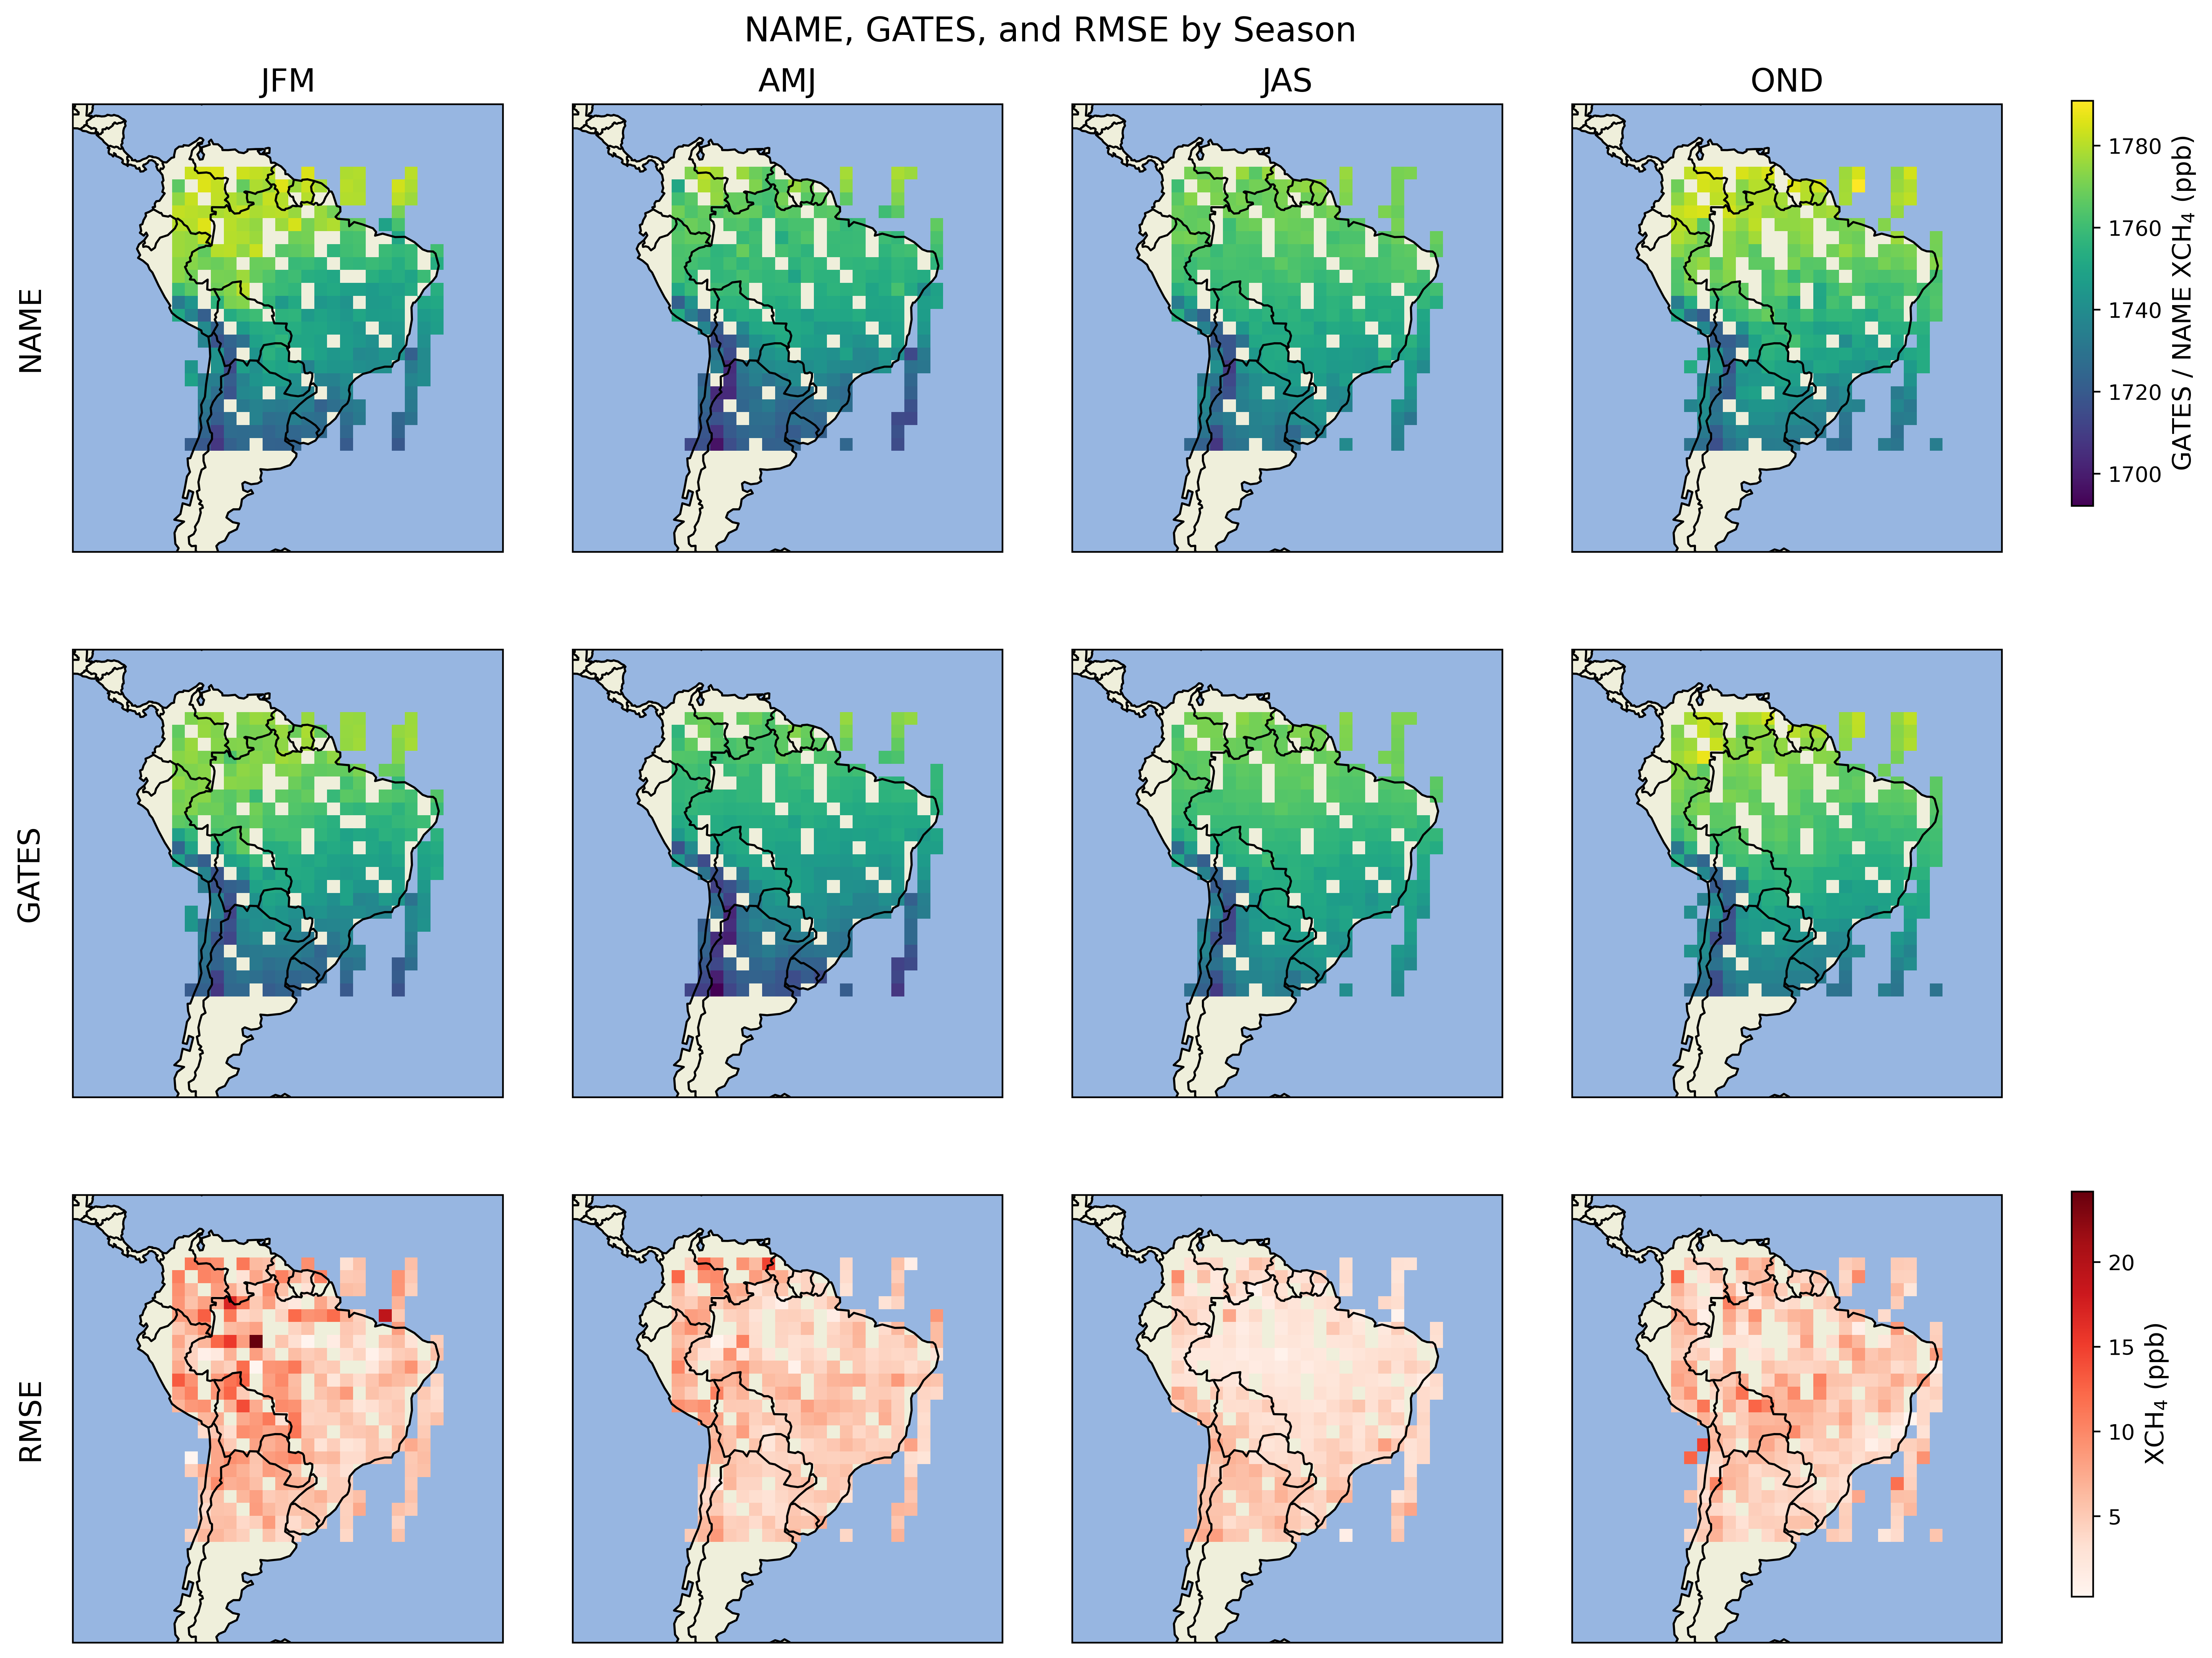

In [25]:
#retrended_denormalized_truths = (truths*output_std) +output_mean + test_correction_values
#retrended_denormalized_predictions = (predictions*output_std) +output_mean + test_correction_values
# Compute the binned arrays

retrended_denormalized_truths_ppb =retrended_denormalized_truths*1e9 
retrended_denormalized_predictions_ppb = retrended_denormalized_predictions*1e9
#(predictions*output_std) +output_mean + test_correction_values

season_truths, season_preds, season_mses, lat_edges, lon_edges = compute_binned_truth_pred(
    retrended_denormalized_truths_ppb,#denormalized_truths, 
    retrended_denormalized_predictions_ppb,#denormalized_predictions, 
    ds_subset["time"], 
    ds_subset["release_lat"].values, 
    ds_subset["release_lon"].values,
    degree_bins=2
)



# Plot them in 3-row seasonal map
plot_seasonal_truth_pred_mse_shared_cbar(
    season_results = {"JFM":{"mses_binned":season_mses["JFM"], "lat_edges":lat_edges, "lon_edges":lon_edges},
                      "AMJ":{"mses_binned":season_mses["AMJ"], "lat_edges":lat_edges, "lon_edges":lon_edges},
                      "JAS":{"mses_binned":season_mses["JAS"], "lat_edges":lat_edges, "lon_edges":lon_edges},
                      "OND":{"mses_binned":season_mses["OND"], "lat_edges":lat_edges, "lon_edges":lon_edges}},
    ground_truth_results=season_truths,
    prediction_results=season_preds,
    domain_lats=ds_subset["lat"].values,
    domain_lons=ds_subset["lon"].values,
    region="SOUTHAMERICA"
)

# Box and whisker plot

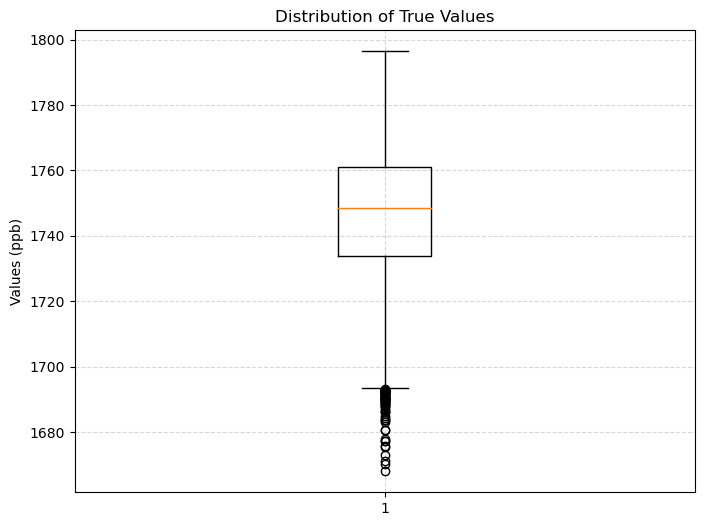

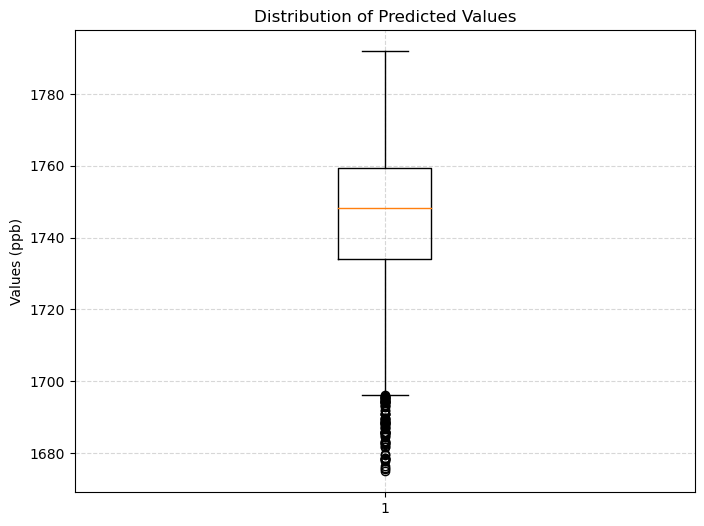

In [25]:
plt.figure(figsize=(8,6))
plt.boxplot(denormalized_truths, vert=True)
plt.ylabel("Values (ppb)")
plt.title("Distribution of True Values")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


plt.figure(figsize=(8,6))
plt.boxplot(denormalized_predictions, vert=True)
plt.ylabel("Values (ppb)")
plt.title("Distribution of Predicted Values")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

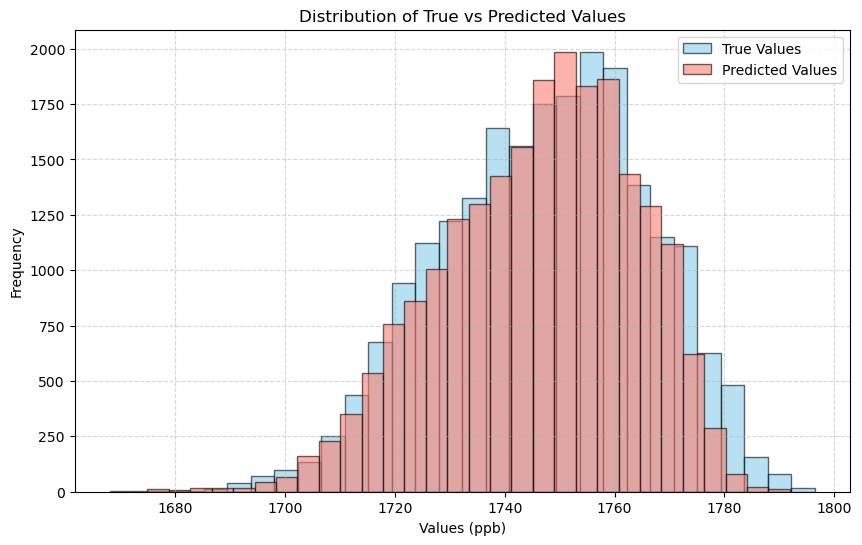

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Histogram for True Values
plt.hist(
    denormalized_truths.flatten(),
    bins=30,
    color='skyblue',
    alpha=0.6,
    edgecolor='black',
    label='True Values'
)

# Histogram for Predicted Values
plt.hist(
    denormalized_predictions.flatten(),
    bins=30,
    color='salmon',
    alpha=0.6,
    edgecolor='black',
    label='Predicted Values'
)

plt.xlabel("Values (ppb)")
plt.ylabel("Frequency")
plt.title("Distribution of True vs Predicted Values")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

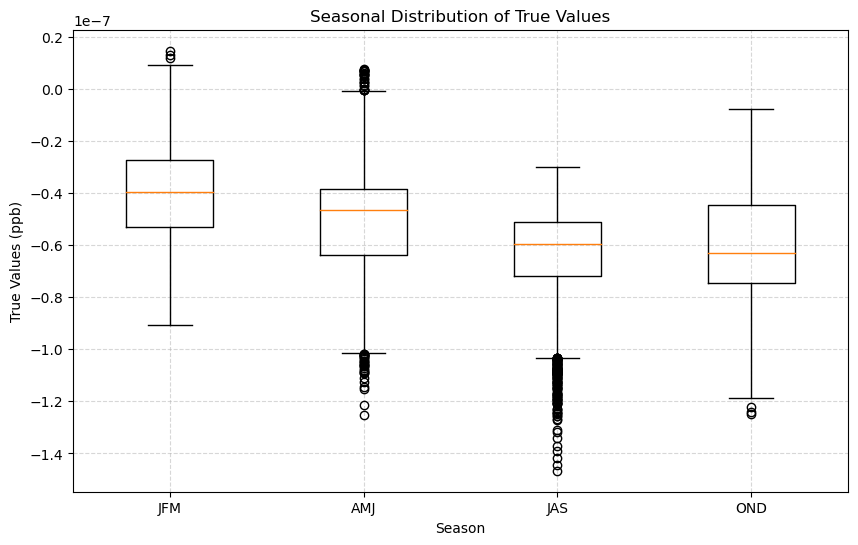

In [22]:
import pandas as pd
import numpy as np

# Example: dates = ds_subset['time'].values
# Ensure dates is a pandas datetime array

dates = pd.to_datetime(ds_subset['time'].values)

# Define seasons
seasons = {
    "JFM": [1,2,3],
    "AMJ": [4,5,6],
    "JAS": [7,8,9],
    "OND": [10,11,12]
}

seasonal_truths = {key: [] for key in seasons.keys()}
seasonal_preds = {key: [] for key in seasons.keys()}
# Assign values to seasons
for season, months in seasons.items():
    idxs = [i for i, d in enumerate(dates) if d.month in months]
    seasonal_truths[season] = denormalized_truths[idxs]
    seasonal_preds[season] = denormalized_predictions[idxs]

# Plot
plt.figure(figsize=(10,6))
plt.boxplot([seasonal_truths[s].flatten() for s in seasons.keys()], labels=seasons.keys())
plt.ylabel("True Values (ppb)")
plt.xlabel("Season")
plt.title("Seasonal Distribution of True Values")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

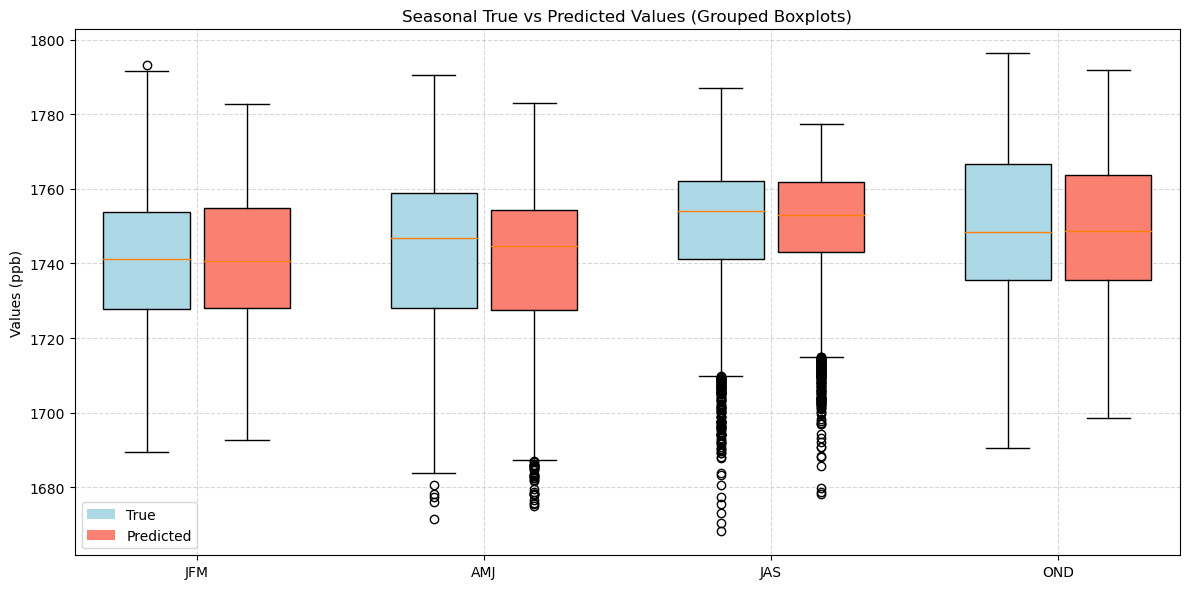

In [28]:
season_list = list(seasons.keys())   # ['JFM','AMJ','JAS','OND']
n_seasons = len(season_list)

truth_data = [seasonal_truths[s].flatten() for s in season_list]
pred_data  = [seasonal_preds[s].flatten()  for s in season_list]

plt.figure(figsize=(12,6))

positions_truth = np.arange(n_seasons) * 2.0
positions_pred  = positions_truth + 0.7

plt.boxplot(truth_data, positions=positions_truth, widths=0.6,
            patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.boxplot(pred_data, positions=positions_pred, widths=0.6,
            patch_artist=True, boxprops=dict(facecolor="salmon"))

plt.xticks(positions_truth + 0.35, season_list)
plt.ylabel("Values (ppb)")
plt.title("Seasonal True vs Predicted Values (Grouped Boxplots)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend([plt.Rectangle((0,0),1,1,facecolor="lightblue"),
            plt.Rectangle((0,0),1,1,facecolor="salmon")],
           ["True", "Predicted"])

plt.tight_layout()
plt.show()

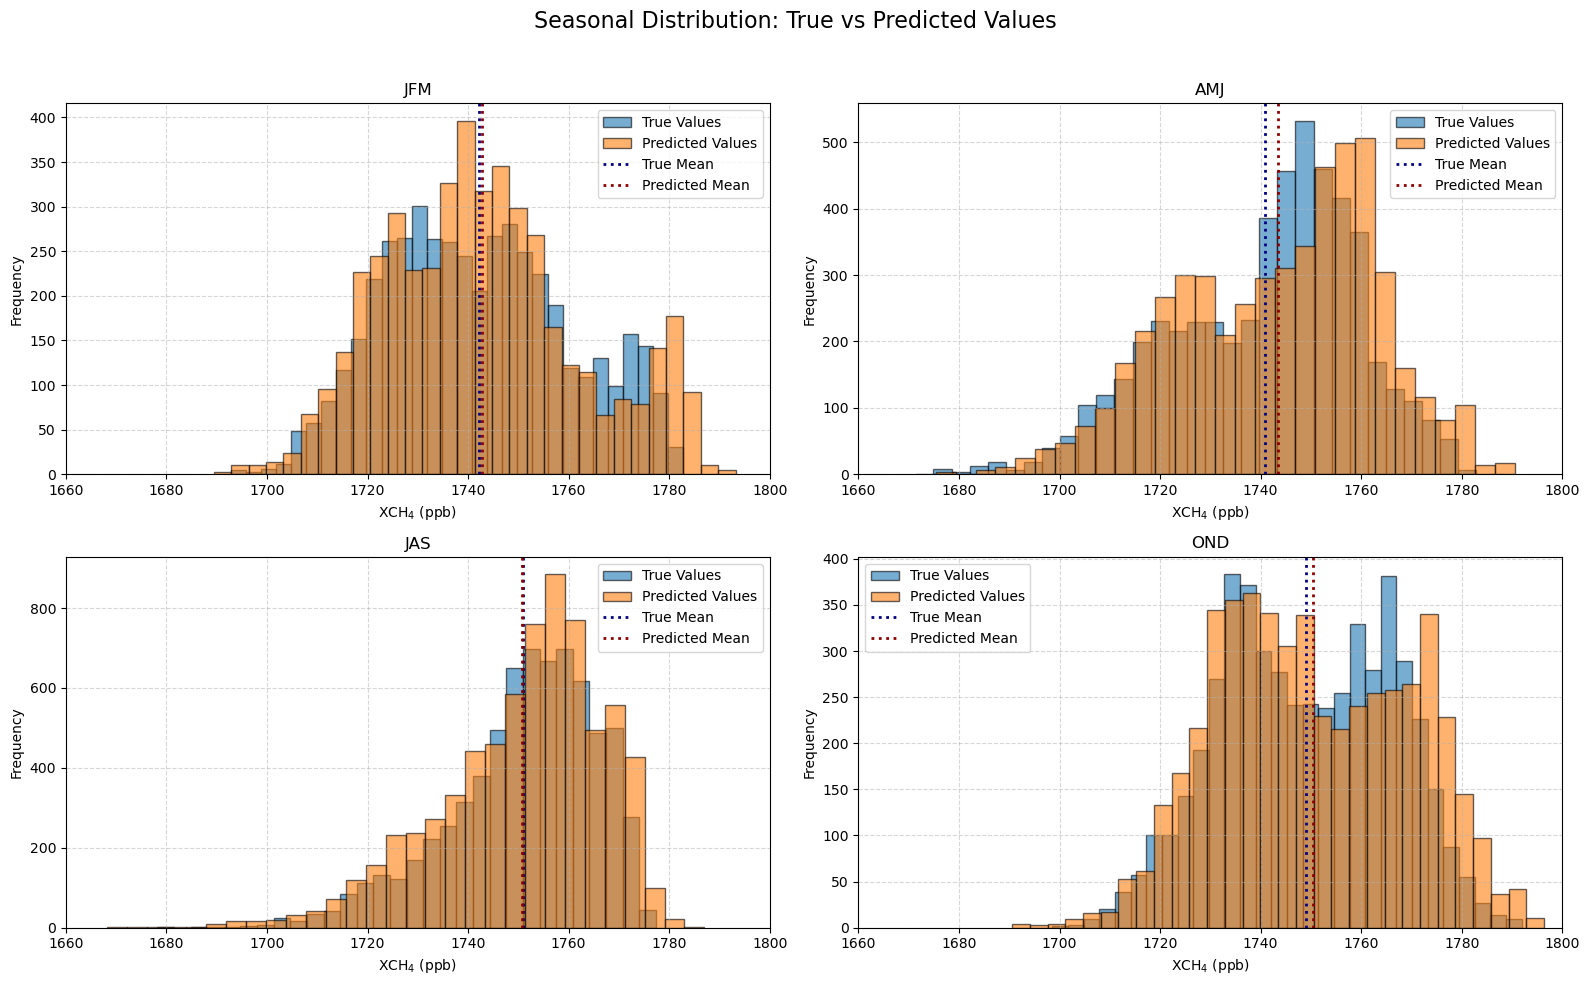

In [27]:
import matplotlib.pyplot as plt
'''
# Define seasons and their months
seasons = {
    "Q1 (Jan–Mar)": [1, 2, 3],
    "Q2 (Apr–Jun)": [4, 5, 6],
    "Q3 (Jul–Sep)": [7, 8, 9],
    "Q4 (Oct–Dec)": [10, 11, 12],
}
'''

'''
seasons = {
    "JFM": [1, 2, 3],
    "AMJ": [4, 5, 6],
    "JAS": [7, 8, 9],
    "OND": [10, 11, 12],
}

# Extract month from time
months = ds_subset["time"].dt.month.values

plt.figure(figsize=(16, 10))

# Loop through seasons
for i, (season_name, season_months) in enumerate(seasons.items(), 1):
    plt.subplot(2, 2, i)
    
    # Mask the indices for this season
    season_idx = np.isin(months, season_months)
    
    # Extract seasonal data
    #truth_season = denormalized_truths[season_idx]
    #pred_season = denormalized_predictions[season_idx]

    truth_season = retrended_denormalized_predictions_ppb[season_idx]
    pred_season =  retrended_denormalized_truths_ppb[season_idx]
    
    # Plot overlapping histograms
    plt.hist(truth_season, bins=30, color='skyblue', alpha=0.6, edgecolor='black', label='True Values')
    plt.hist(pred_season, bins=30, color='salmon', alpha=0.6, edgecolor='black', label='Predicted Values')
    
    plt.title(season_name)
    plt.xlabel("Values (ppb)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

plt.suptitle("Seasonal Distribution: True vs Predicted Values", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
'''


import numpy as np
import matplotlib.pyplot as plt

seasons = {
    "JFM": [1, 2, 3],
    "AMJ": [4, 5, 6],
    "JAS": [7, 8, 9],
    "OND": [10, 11, 12],
}

# Extract month from time
months = ds_subset["time"].dt.month.values

plt.figure(figsize=(16, 10))

for i, (season_name, season_months) in enumerate(seasons.items(), 1):
    plt.subplot(2, 2, i)
    
    # Mask indices for this season
    season_idx = np.isin(months, season_months)
    
    # Extract seasonal data
    truth_season = retrended_denormalized_predictions_ppb[season_idx]
    pred_season =  retrended_denormalized_truths_ppb[season_idx]
    
    # Plot histograms
    plt.hist(
        truth_season, bins=30, alpha=0.6, edgecolor='black',
        label='True Values'
    )
    plt.hist(
        pred_season, bins=30, alpha=0.6, edgecolor='black',
        label='Predicted Values'
    )
    
    # Compute means
    truth_mean = np.mean(truth_season)
    pred_mean = np.mean(pred_season)
    
    # Plot mean lines
    plt.axvline(truth_mean, color='navy', linestyle=':', linewidth=2, label='True Mean')
    plt.axvline(pred_mean, color='darkred', linestyle=':', linewidth=2, label='Predicted Mean')
    
    # Set x-axis limits
    plt.xlim(1660, 1800)
    
    plt.title(season_name)
    plt.xlabel(r"XCH$_4$ (ppb)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

plt.suptitle("Seasonal Distribution: True vs Predicted Values", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("seasonal_distribution_150325.png", format="png",bbox_inches="tight")
plt.show()



### Make dataframe table

In [24]:
import numpy as np
import pandas as pd

results = []

for season_name, season_months in seasons.items():
    # Mask indices for this season
    season_idx = np.isin(months, season_months)
    
    truth_season = retrended_denormalized_predictions_ppb[season_idx]
    pred_season =  retrended_denormalized_truths_ppb[season_idx]
    
    # Error
    error = pred_season - truth_season
    
    # Metrics
    bias = np.mean(error)
    rmse = np.sqrt(np.mean(error**2))
    sigma = np.sqrt(rmse**2 - bias**2)
    
    results.append({
        "Season": season_name,
        "Bias (ppb)": bias,
        "RMSE (ppb)": rmse,
        "σ(error) (ppb)": sigma
    })


df_metrics = pd.DataFrame(results)

# Optional: round for presentation
df_metrics = df_metrics.round({
    "Bias (ppb)": 2,
    "RMSE (ppb)": 2,
    "σ(error) (ppb)": 2
})

df_metrics

,Season,Bias (ppb),RMSE (ppb),σ(error) (ppb)
0,JFM,0.72,7.44,7.41
1,AMJ,2.74,6.58,5.98
2,JAS,-0.07,5.26,5.26
3,OND,1.35,6.38,6.23


### Additional plots of full data

In [28]:
from graphnet_LPDM_emulator.model.bc_figures import *

In [29]:
with open("correction_values_full.pkl", "rb") as f:
    correction_values = pickle.load(f)

test_correction_values = correction_values['test_correction_values']
test_correction_values = test_correction_values.reshape(-1,1)
print(test_correction_values .shape)
# suppose your array is called arr
print("Max value:", np.nanmax(test_correction_values))       # safe max that ignores NaNs
print("Any NaNs present?:", np.isnan(test_correction_values).any())

(21989, 1)
Max value: 1.8168010937353404e-06
Any NaNs present?: False


In [2]:
ds = xr.open_dataset("test_subset_full.nc")
ds

<xarray.Dataset>
Dimensions:      (time: 21348, lat: 357, lon: 190)
Coordinates:
  * time         (time) datetime64[ns] 2016-01-01T14:59:12.500000 ... 2016-12...
  * lat          (lat) float32 -60.98 -60.75 -60.51 -60.28 ... 21.85 22.09 22.32
  * lon          (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon  (time) float32 ...
    release_lat  (time) float32 ...
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-29 20:05:49.874413

In [11]:
print(ds.time.values)

['2016-01-01T14:59:12.500000000' '2016-01-01T16:33:10.000000000'
 '2016-01-01T16:33:33.000000000' ... '2016-12-31T16:15:42.000000000'
 '2016-12-31T17:43:58.000000000' '2016-12-31T17:44:35.000000000']


In [5]:
with open('truth_pred_data_full.pkl', 'rb') as file:
    data = pickle.load(file)
    

dict_keys(['truth', 'predictions'])

In [30]:
ds = xr.open_dataset("test_subset_full.nc")
with open('truth_pred_data_full.pkl', 'rb') as file:
    data = pickle.load(file)

#ds = ds.assign({'true_bc_detrended': (('time'), 1e9*(data["truth"].flatten())})
ds = ds.assign({'true_bc_detrended': (('time'), 1e9*data["truth"].flatten())})
ds = ds.assign({'pred_bc_detrended': (('time'), 1e9*data["predictions"].flatten())})
attrs = {"units":"ppb", "domain": "SOUTHAMERICA", "model_name":"example_name", "parameter_file":"parameter_file", "created_on":str(datetime.now()), "created_by":"nawid's username"}
ds = ds.assign_attrs(attrs)

In [31]:
retrended_dataset = retrend_predictions_cams(ds)

In [32]:
retrended_dataset

<xarray.Dataset>
Dimensions:            (time: 21989, lat: 357, lon: 190)
Coordinates:
  * time               (time) datetime64[ns] 2017-01-01T15:01:57 ... 2017-12-...
  * lat                (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon        (time) float32 ...
    release_lat        (time) float32 ...
    true_bc_detrended  (time) float64 -23.38 -28.21 -28.06 ... -74.61 -74.39
    pred_bc_detrended  (time) float64 -21.74 -22.58 -22.75 ... -83.44 -83.44
    true_bc_flux       (time) float64 1.762e+03 1.757e+03 ... 1.729e+03 1.73e+03
    pred_bc_flux       (time) float64 1.763e+03 1.762e+03 ... 1.721e+03
Attributes:
    max_level:       17
    author:          rt17603
    created:         2019-05-06 23:39:16.891007
    units:           ppb
    domain:          SOUTHAMERICA
    model_name:      example_name
    parameter_file:  parameter_file
    created_on:      2026-03-15 16:22:48.187266
    created_by:      nawid's username

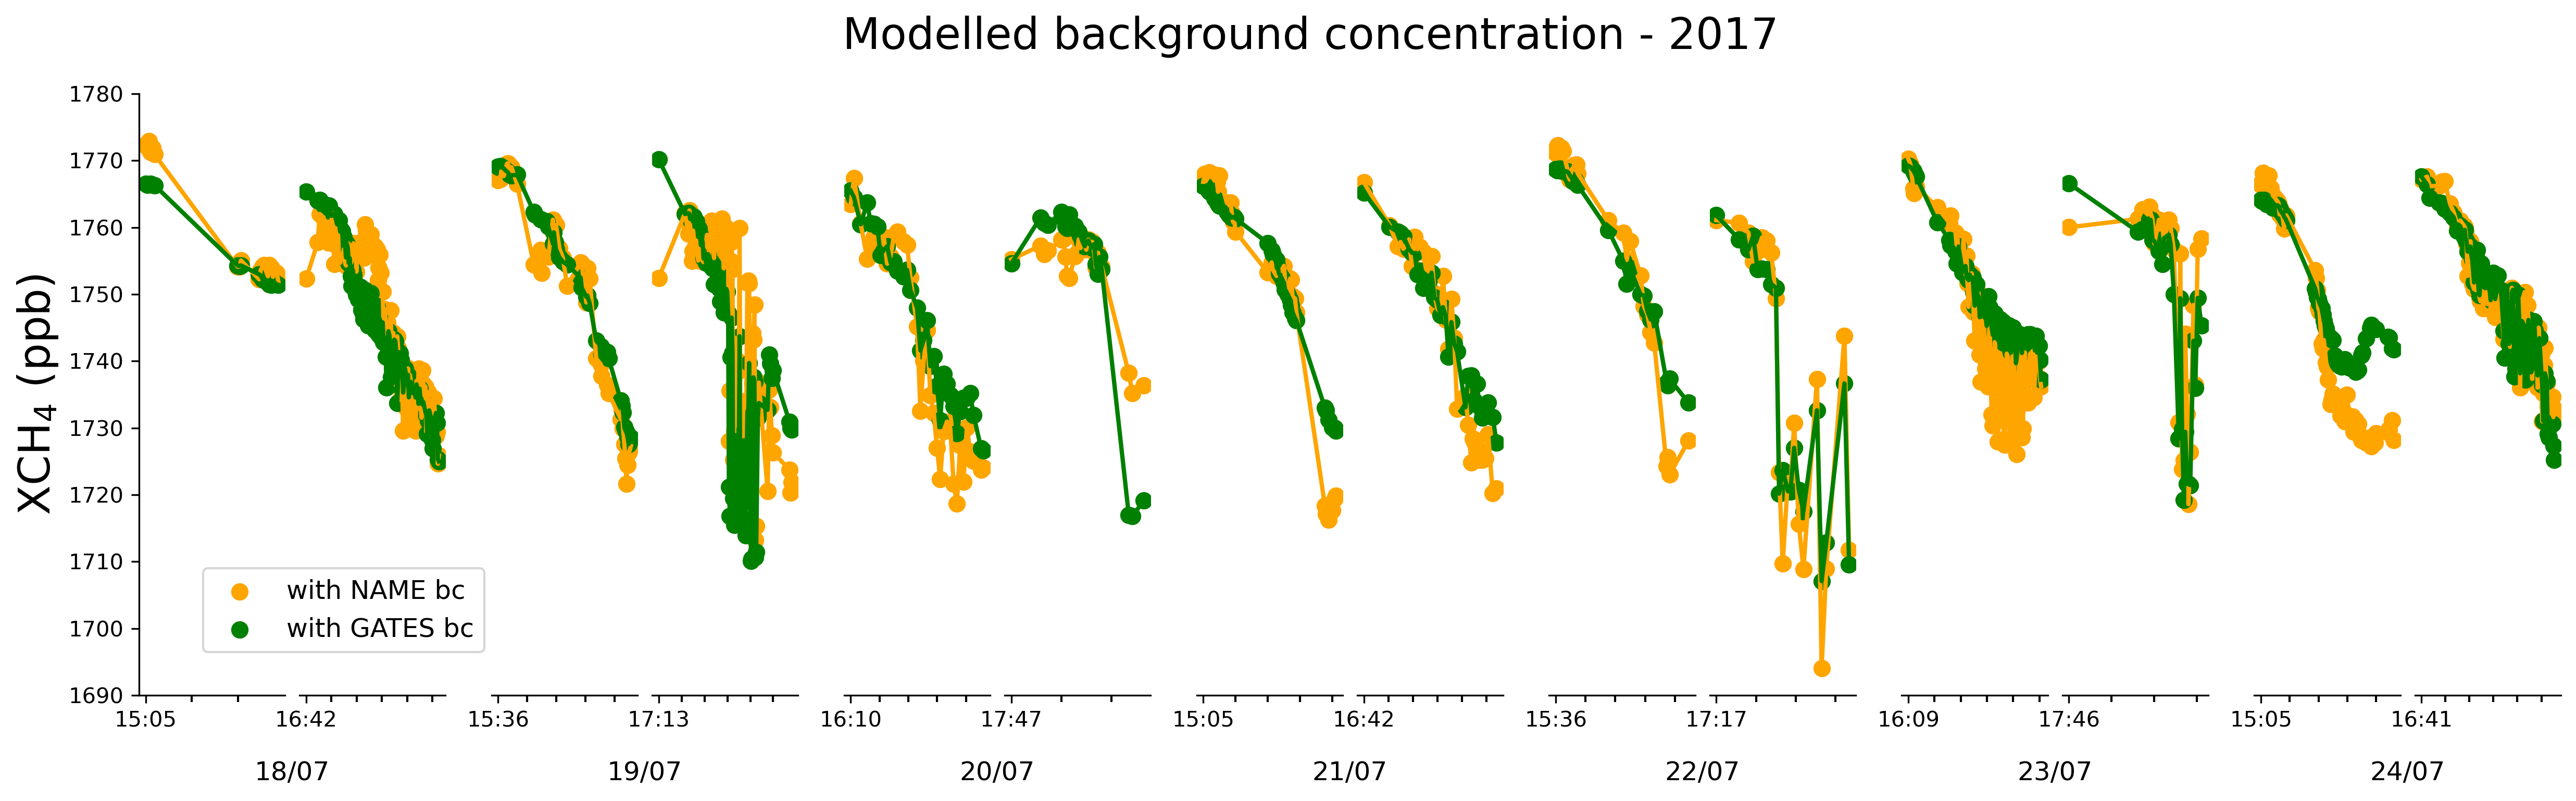

In [33]:
start_date = "2017-07-18"
plot_bc_timeseries(retrended_dataset, start_date,ylim=[1690,1780], attribute_name="bc_flux")

In [8]:
date = "2017"
fp_file = xr.open_mfdataset(glob.glob(f"/group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{date}*.nc"))

# align the footprint and the bc dataset, along the time axis
valid_dates = np.intersect1d(fp_file.time.values, ds.time.values)
fp_file = fp_file.sel(time=valid_dates)
fp_file.load() # load for faster plotting
ds = ds.sel(time=valid_dates)

/user/work/yl18410/graphnet_bp_220324_backup/lib/python3.9/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


# 2018

In [4]:
import numpy as np

# Load the archive
data = np.load('predictions_2018.npz')

# See what's inside
print("Keys in the file:", data.files)

# Extract the arrays (adjust keys if yours are named differently)
preds = data['predictions']
truths = data['truths']

print(f"Predictions shape: {preds.shape}")
print(f"Truths shape: {truths.shape}")

# Calculate the raw difference
residual = preds - truths

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(residual))

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(residual**2))

print(f"Global MAE: {mae}")
print(f"Global RMSE: {rmse}")

Keys in the file: ['predictions', 'truths']
Predictions shape: (1339,)
Truths shape: (1339,)
Global MAE: 1.5737601541126132e-08
Global RMSE: 1.9444887894248645e-08


In [5]:
import xarray as xr

# Load the dataset
ds = xr.open_dataset('full_year_coords_2018.nc')

# Print the structure to see your variables and coordinates
print(ds)

# Access specific data
predictions = ds['predictions'].values
truths = ds['truths'].values
times = ds['time'].values

<xarray.Dataset>
Dimensions:      (time: 1339, lat: 357, lon: 190)
Coordinates:
  * time         (time) datetime64[ns] 2018-01-01T16:18:34 ... 2018-12-31T16:...
  * lat          (lat) float32 -60.98 -60.75 -60.51 -60.28 ... 21.85 22.09 22.32
  * lon          (lon) float32 -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
Data variables:
    release_lon  (time) float32 ...
    release_lat  (time) float32 ...
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-10-12 18:59:07.685513


KeyError: 'predictions'